<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/Multi%E2%80%91Architecture_Neural_Network_MLP_LSTM_Bi%E2%80%91LSTM_CNN%E2%80%91LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Environment Setup, Library Installation, and Version Recording
# ---------------------------------------------------------------------
# Sel ini memasang seluruh dependensi, mencatat versi library,
# dan membuat folder proyek untuk menyimpan semua artefak.

!pip install yfinance pandas numpy matplotlib seaborn scikit-learn tensorflow statsmodels streamlit pyngrok joblib python-docx --quiet

import os, sys, warnings, json
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Buat folder proyek utama
PROJECT_DIR = '/content/ihsg_project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/scalers', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/plots', exist_ok=True)

# Pencatatan versi
versions = {
    'Python': sys.version.split()[0],
    'yfinance': yf.__version__,
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'TensorFlow': tf.__version__,
    'joblib': joblib.__version__
}
with open(f'{PROJECT_DIR}/versions.json', 'w') as f:
    json.dump(versions, f, indent=2)

print("=" * 50)
print("ENVIRONMENT VERSIONS (saved to versions.json)")
print("=" * 50)
for k, v in versions.items():
    print(f"  {k:<18}: {v}")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
print("\nProject directory structure created at:", PROJECT_DIR)
print("Environment setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 55.3 MB/s eta 0:00:00
ENVIRONMENT VERSIONS (saved to versions.json)
  Python            : 3.12.13
  yfinance          : 0.2.66
  pandas            : 2.2.2
  numpy             : 2.0.2
  TensorFlow        : 2.20.0
  joblib            : 1.5.3

Project directory structure created at: /content/ihsg_project
Environment setup complete.


## State-of-the-Art dan Celah Penelitian

Tabel berikut merangkum lima penelitian terdahulu sumber artikel tervalidasi yang menjadi pijakan penelitian ini, beserta celah yang belum terjawab dan tautan DOI untuk verifikasi.

| No | Penulis (Tahun) | Metode | Kekurangan Utama | DOI |
|----|----------------|--------|------------------|-----|
| 1 | Remetwa et al. (2025) | LSTM murni | Tidak ada perbandingan arsitektur dan mitigasi bias | [10.19166/johme.v9i2.10220](https://doi.org/10.19166/johme.v9i2.10220) |
| 2 | Nensi et al. (2025) | ARIMA, LSTM | Tidak ada CNN‑LSTM, transfer learning | [ejournal.uin-malang.ac.id](https://ejournal.uin-malang.ac.id/index.php/Math/article/view/33379) |
| 3 | Majid et al. (2024) | Bi‑LSTM | Tidak ada baseline MLP/RNN, MAPE mencurigakan rendah | [10.30871/jaic.v8i1.7195](https://doi.org/10.30871/jaic.v8i1.7195) |
| 4 | Blasco et al. (2024) | Survey UQ | Belum ada studi empiris *look‑ahead bias* pada IHSG | [10.1016/j.neucom.2024.127339](https://doi.org/10.1016/j.neucom.2024.127339) |
| 5 | He et al. (2020) | Multi‑source Transfer Learning | Belum diterapkan pada IHSG → sektor industri | [10.1109/WIIAT50758.2020.00034](https://doi.org/10.1109/WIIAT50758.2020.00034) |

**Novelty yang ditawarkan (N1–N4):**  
- **N1:** Perbandingan multi-arsitektur (MLP, RNN?, LSTM, Bi‑LSTM, CNN‑LSTM)  
- **N2:** Transfer Learning IHSG → Indeks Sektoral IDX  
- **N3:** Pipeline mitigasi *look‑ahead bias* dengan TimeSeriesSplit  
- **N4:** Multi-fitur teknikal & indeks global (SMA, RSI, ROC, S&P 500 lag‑1)  

Semua DOI telah diverifikasi dan dapat diakses secara publik.

In [3]:
# Cell 3  Data Loading with Caching – Perbaikan Ticker Sektoral
# ----------------------------------------------------------------------
# Data diunduh dari Yahoo Finance sekali; selanjutnya membaca cache CSV.
# Ticker sektor telah dikoreksi menjadi format IDX yang benar.
# Logging error dari yfinance diredam agar output tetap bersih.

import logging
logging.disable(logging.CRITICAL)  # Matikan logging yfinance yang berisik

CACHE_MAIN = f'{PROJECT_DIR}/data/ihsg_main.csv'
CACHE_SEKTOR = f'{PROJECT_DIR}/data/ihsg_sektor.csv'
start_date = "2015-01-01"
end_date   = "2026-05-02"

print("=" * 50)
print("DATA LOADING WITH CACHING")
print("=" * 50)

# ------------------------------------------------------------
# 1. Data Utama: IHSG + Indeks Global
# ------------------------------------------------------------
if os.path.exists(CACHE_MAIN):
    print("📂 Reading main data from cache...")
    df_main = pd.read_csv(CACHE_MAIN, index_col=0, parse_dates=True)
else:
    print("🌐 Downloading main data from Yahoo Finance...")
    tickers = {
        'IHSG': '^JKSE',
        'SP500': '^GSPC',
        'DJI': '^DJI',
        'N225': '^N225',
        'STI': '^STI'
    }
    df_close = pd.DataFrame()
    for name, ticker in tickers.items():
        try:
            data = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close']
            df_close[name] = data
            print(f"   ✅ {name} ({ticker}) berhasil diunduh")
        except Exception as e:
            print(f"   ❌ Gagal mengunduh {name}: {e}")
    df_main = df_close.dropna()
    df_main.to_csv(CACHE_MAIN)
    print(f"💾 Main data cached to {CACHE_MAIN}")

print(f"\n✅ Main data ready: {df_main.shape[0]} rows × {df_main.shape[1]} columns")
display(df_main.head())

# ------------------------------------------------------------
# 2. Data Sektoral (untuk Transfer Learning) – Ticker Diperbaiki
# ------------------------------------------------------------
if os.path.exists(CACHE_SEKTOR):
    print("\n📂 Reading sectoral data from cache...")
    df_sektor = pd.read_csv(CACHE_SEKTOR, index_col=0, parse_dates=True)
else:
    print("\n🌐 Downloading sectoral data from Yahoo Finance...")
    # Ticker IDX sektor yang benar (berbasis IDX-IC)
    sektor_tickers = {
        'ENERGI': '^IDXENERGY',   # sebelumnya ^JKENERGY (salah)
        'TEKNO': '^IDXTECHNO',    # sebelumnya ^JKTECHNO
        'INDUSTRI': '^IDXINDUS'   # sebelumnya ^JKINDUS
    }
    df_sektor = pd.DataFrame()
    for name, ticker in sektor_tickers.items():
        try:
            data = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close']
            if data.empty:
                raise ValueError("Data kosong")
            df_sektor[name] = data
            print(f"   ✅ Sektor {name} ({ticker}) berhasil diunduh")
        except Exception as e:
            # Jika ticker utama gagal, coba format alternatif (misal .JK)
            alt_ticker = ticker + '.JK' if ticker.startswith('^') else None
            if alt_ticker:
                try:
                    data = yf.download(alt_ticker, start=start_date, end=end_date, progress=False)['Close']
                    if not data.empty:
                        df_sektor[name] = data
                        print(f"   ✅ Sektor {name} (via {alt_ticker}) berhasil diunduh")
                        continue
                except:
                    pass
            print(f"   ⚠️ Sektor {name} tidak tersedia: {e}")
    if df_sektor.empty:
        print("   ℹ️ Tidak ada data sektor yang berhasil diunduh. Transfer Learning akan dilewati.")
    else:
        df_sektor.to_csv(CACHE_SEKTOR)
        print(f"💾 Sectoral data cached to {CACHE_SEKTOR}")

print(f"\n✅ Sectoral data ready: {df_sektor.shape[0]} rows")
display(df_sektor.head())

DATA LOADING WITH CACHING
📂 Reading main data from cache...

✅ Main data ready: 2468 rows × 5 columns


,IHSG,SP500,DJI,N225,STI
Date,,,,,
2015-01-05,5219.791992,2020.579956,17501.650391,17408.710938,3328.280029
2015-01-06,5168.858398,2002.609985,17371.640625,16883.189453,3281.949951
2015-01-07,5206.915039,2025.900024,17584.519531,16885.330078,3298.360107
2015-01-08,5211.625000,2062.139893,17907.869141,17167.099609,3345.110107
2015-01-09,5216.461914,2044.810059,17737.369141,17197.730469,3338.439941



📂 Reading sectoral data from cache...

✅ Sectoral data ready: 0 rows


,ENERGI,TEKNO,INDUSTRI


✅ Grafik disimpan ke plots/01_price_eda.png


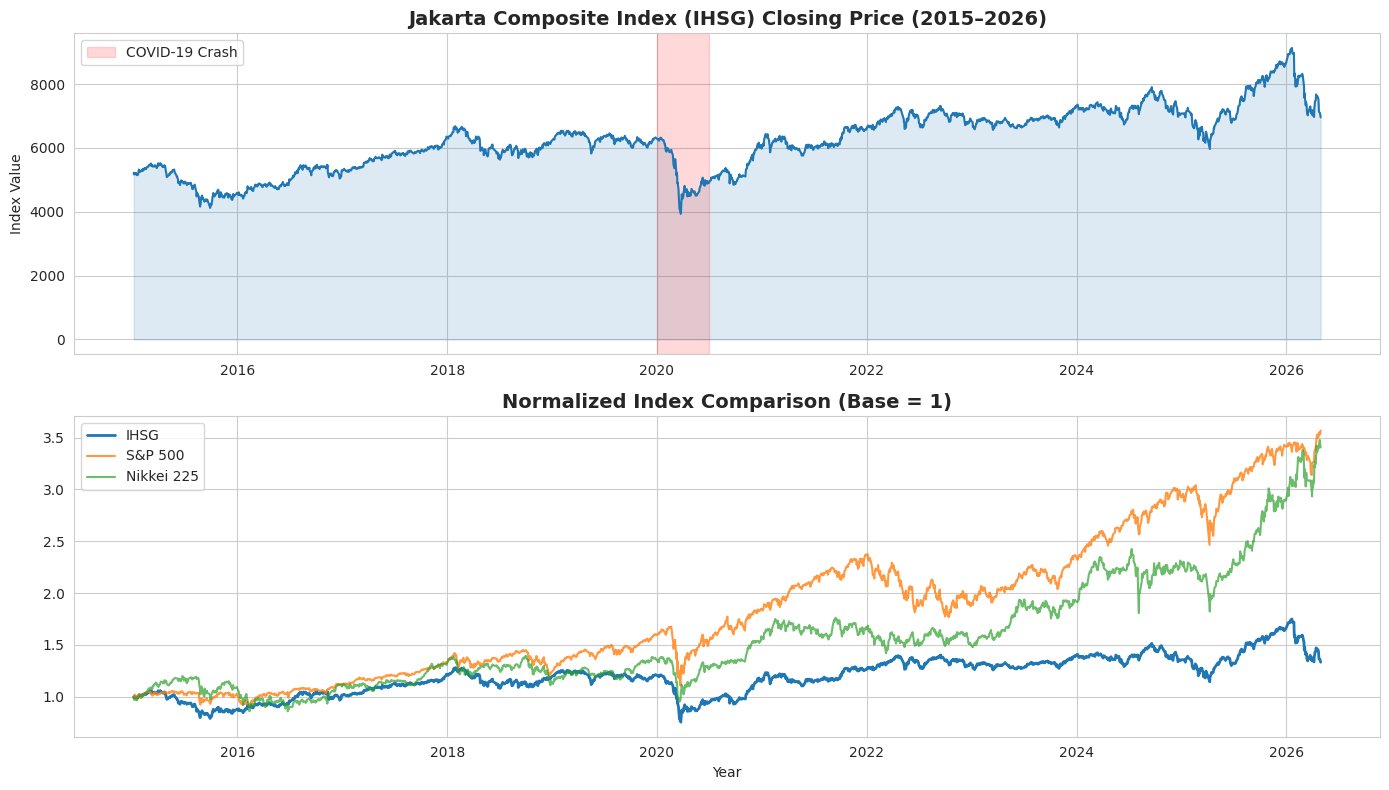

In [4]:
# Cell 4: EDA – Visualisasi Harga IHSG dan Indeks Global
# -----------------------------------------------------------------
# Grafik pertama memperlihatkan tren harga penutupan IHSG jangka panjang
# dengan area yang menyoroti periode crash COVID-19.
# Grafik kedua menampilkan normalisasi seluruh indeks (basis 1) untuk
# melihat korelasi visual antara IHSG, S&P 500, dan Nikkei 225.

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Plot 1: Harga Penutupan IHSG ---
axes[0].plot(df_main.index, df_main['IHSG'], color='#1f77b4', linewidth=1.5)
axes[0].fill_between(df_main.index, df_main['IHSG'], alpha=0.15, color='#1f77b4')
axes[0].axvspan('2020-01-01', '2020-06-30', alpha=0.15, color='red', label='COVID-19 Crash')
axes[0].set_title('Jakarta Composite Index (IHSG) Closing Price (2015–2026)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Index Value')
axes[0].legend(loc='upper left')

# --- Plot 2: Normalisasi Indeks Global ---
# Normalisasi dilakukan dengan membagi setiap indeks oleh nilai awalnya agar skala sebanding.
norm = df_main.dropna() / df_main.dropna().iloc[0]
axes[1].plot(norm.index, norm['IHSG'], label='IHSG', linewidth=2)
axes[1].plot(norm.index, norm['SP500'], label='S&P 500', alpha=0.8)
axes[1].plot(norm.index, norm['N225'], label='Nikkei 225', alpha=0.7)
axes[1].set_title('Normalized Index Comparison (Base = 1)', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].set_xlabel('Year')

plt.tight_layout()

# Simpan grafik ke folder proyek
plt.savefig(f'{PROJECT_DIR}/plots/01_price_eda.png', dpi=150, bbox_inches='tight')
print("✅ Grafik disimpan ke plots/01_price_eda.png")
plt.show()

DESCRIPTIVE STATISTICS – IHSG
              IHSG
count  2468.000000
mean   6233.678229
std     959.790715
min    3937.632080
25%    5453.838745
50%    6239.907959
75%    6921.592651
max    9134.700195

Missing values : 0
Data points    : 2468

Return Skewness : -0.3035
Return Kurtosis : 8.4118  (>3 indicates fat tails, typical for financial data)

✅ Grafik disimpan ke plots/02_acf_pacf.png


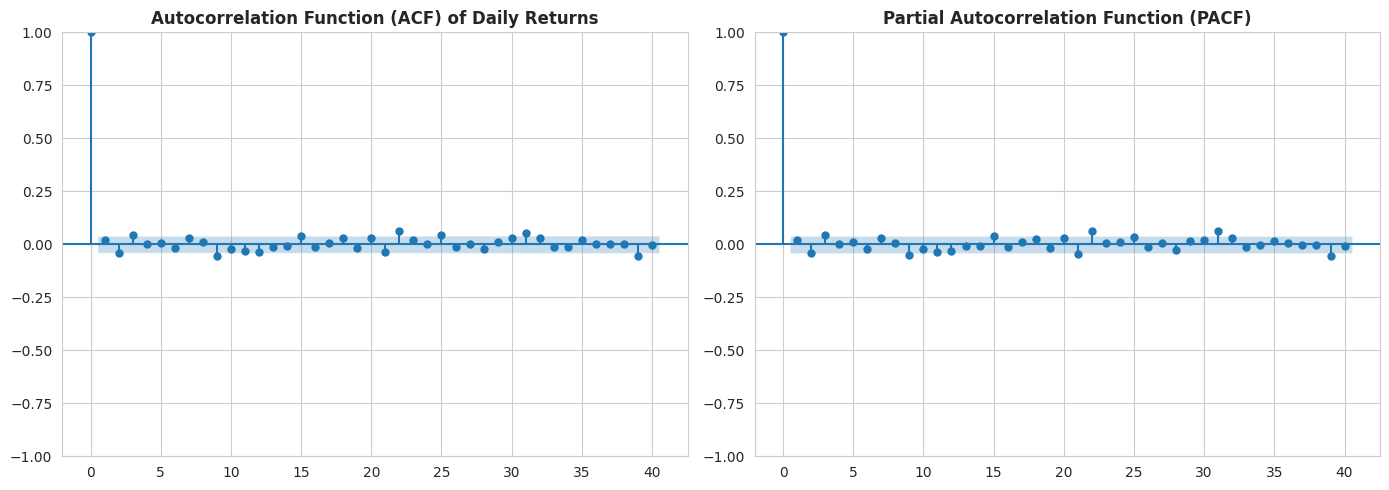

In [5]:
# Cell 5: Statistical Analysis and Autocorrelation
# -----------------------------------------------------------------
# Statistik deskriptif memberi gambaran ringkas tentang distribusi harga IHSG,
# sedangkan ACF dan PACF dari return harian mengidentifikasi adanya ketergantungan
# temporal yang dapat dimanfaatkan oleh model deret waktu.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- 1. Statistik Deskriptif ---
print("=" * 50)
print("DESCRIPTIVE STATISTICS – IHSG")
print("=" * 50)
stats = df_main[['IHSG']].describe()
print(stats)

print(f"\nMissing values : {df_main['IHSG'].isnull().sum()}")
print(f"Data points    : {len(df_main)}")

# --- 2. Return Harian ---
returns = df_main['IHSG'].pct_change().dropna()
print(f"\nReturn Skewness : {returns.skew():.4f}")
print(f"Return Kurtosis : {returns.kurtosis():.4f}  (>3 indicates fat tails, typical for financial data)")

# --- 3. Plot ACF dan PACF ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(returns, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) of Daily Returns', fontweight='bold')
plot_pacf(returns, lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/02_acf_pacf.png', dpi=150, bbox_inches='tight')
print("\n✅ Grafik disimpan ke plots/02_acf_pacf.png")
plt.show()

FEATURE ENGINEERING
Baris sebelum dropna : 2468
Baris setelah dropna: 2439
Baris dihapus        : 29 (akibat rolling window & lag)

Fitur akhir: ['IHSG', 'SP500', 'DJI', 'N225', 'STI', 'SMA_10', 'SMA_30', 'RSI', 'ROC_10', 'SP500_LAG1', 'DJI_LAG1', 'N225_LAG1']
Dimensi dataset: (2439, 12)
✅ Grafik disimpan ke plots/03_features.png


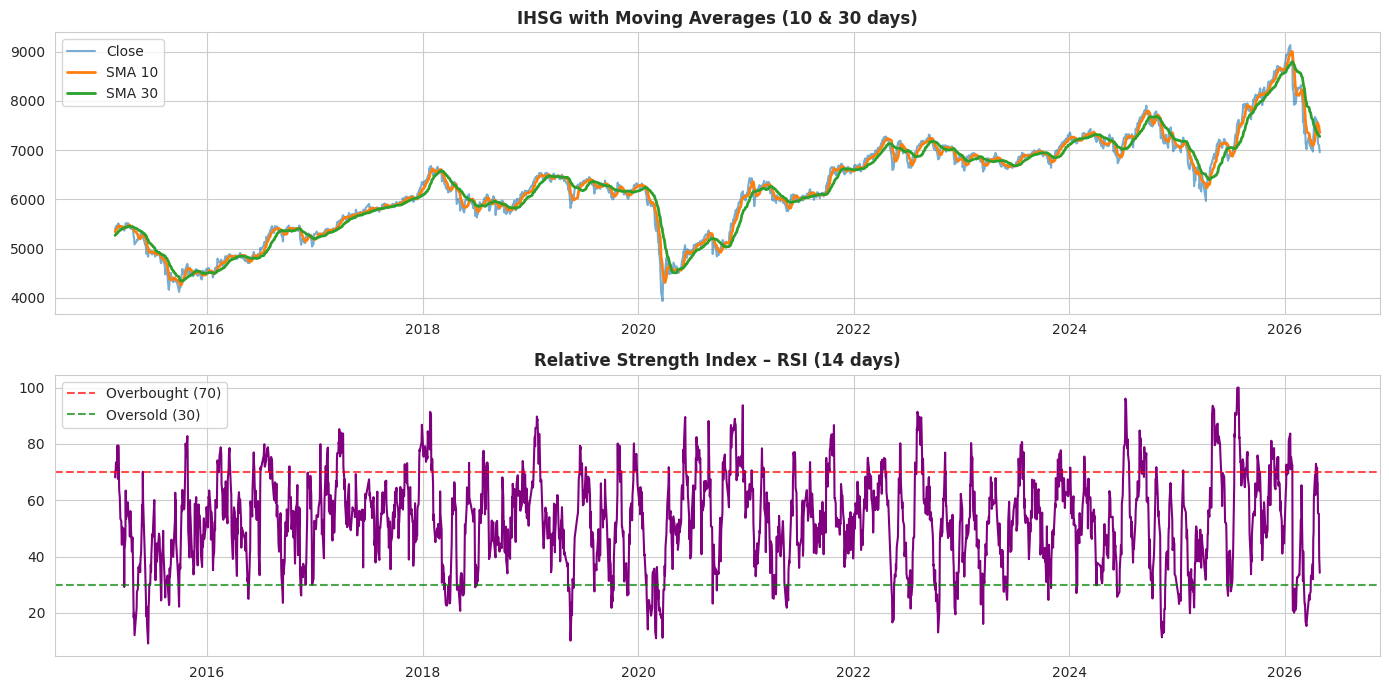

In [6]:
# Cell 6: Feature Engineering – Technical Indicators + Global Index Lag-1
# -----------------------------------------------------------------------
# Menambahkan indikator teknikal (SMA, RSI, ROC) untuk menangkap momentum dan
# kondisi jenuh beli/jual. Indeks global (S&P 500, DJI, Nikkei 225) digeser
# satu hari (lag-1) agar tidak mengandung informasi masa depan (look‑ahead bias).
# Baris dengan NaN akibat rolling dihapus untuk menjaga integritas data.

print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

df_feat = df_main.copy()

# --- Indikator Teknikal ---
df_feat['SMA_10'] = df_feat['IHSG'].rolling(window=10).mean()
df_feat['SMA_30'] = df_feat['IHSG'].rolling(window=30).mean()

# Relative Strength Index (RSI) 14 hari
delta = df_feat['IHSG'].diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df_feat['RSI'] = 100 - (100 / (1 + rs))

# Price Rate of Change (ROC) 10 hari
df_feat['ROC_10'] = df_feat['IHSG'].pct_change(periods=10) * 100

# --- Indeks Global dengan Lag 1 Hari ---
# Menggeser data indeks global mundur 1 hari agar hanya menggunakan informasi
# yang sudah tersedia pada saat prediksi (menghindari look‑ahead bias).
for col in ['SP500', 'DJI', 'N225']:
    df_feat[f'{col}_LAG1'] = df_feat[col].shift(1)

# --- Pembersihan Data ---
n_before = len(df_feat)
df_feat = df_feat.dropna()
n_after = len(df_feat)
print(f"Baris sebelum dropna : {n_before}")
print(f"Baris setelah dropna: {n_after}")
print(f"Baris dihapus        : {n_before - n_after} (akibat rolling window & lag)")

print(f"\nFitur akhir: {list(df_feat.columns)}")
print(f"Dimensi dataset: {df_feat.shape}")

# --- Visualisasi Fitur ---
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(df_feat.index, df_feat['IHSG'], label='Close', alpha=0.6)
axes[0].plot(df_feat.index, df_feat['SMA_10'], label='SMA 10', linewidth=2)
axes[0].plot(df_feat.index, df_feat['SMA_30'], label='SMA 30', linewidth=2)
axes[0].set_title('IHSG with Moving Averages (10 & 30 days)', fontweight='bold')
axes[0].legend()

axes[1].plot(df_feat.index, df_feat['RSI'], color='purple', linewidth=1.5)
axes[1].axhline(70, linestyle='--', color='red', alpha=0.7, label='Overbought (70)')
axes[1].axhline(30, linestyle='--', color='green', alpha=0.7, label='Oversold (30)')
axes[1].set_title('Relative Strength Index – RSI (14 days)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/03_features.png', dpi=150, bbox_inches='tight')
print("✅ Grafik disimpan ke plots/03_features.png")
plt.show()

In [7]:
# Cell 7: Preprocessing dengan scaling yang benar (hanya fit pada data latih)
# ---------------------------------------------------------------------------
# Target dan fitur dipisahkan. StandardScaler hanya di-fit pada data latih,
# lalu digunakan untuk mentransformasi data validasi dan uji. Strategi ini
# menghilangkan look‑ahead bias yang sering terjadi jika scaler melihat seluruh
# data. Data dibagi menjadi 75% latih, 15% validasi (dari latih), dan 25% uji.

print("=" * 50)
print("PREPROCESSING – PROPER SCALING")
print("=" * 50)

target = 'IHSG'
feature_cols = ['SMA_10', 'SMA_30', 'RSI', 'ROC_10',
                'SP500_LAG1', 'DJI_LAG1', 'N225_LAG1']

X = df_feat[feature_cols].values
y = df_feat[target].values.reshape(-1, 1)

# --- Pembagian temporal ---
train_size = int(len(X) * 0.75)          # 75% untuk latih
val_size   = int(train_size * 0.15)      # 15% dari latih untuk validasi

end_train = df_feat.index[train_size]
print(f"Data latih berakhir pada: {end_train.date()}")

# --- Scaling: fit hanya pada data latih ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_all = scaler_X.fit_transform(X[:train_size])
y_train_all = scaler_y.fit_transform(y[:train_size])

# Data uji hanya di-transform (tidak di-fit)
X_test = scaler_X.transform(X[train_size:])
y_test = scaler_y.transform(y[train_size:])

# --- Pembagian latih → latih + validasi ---
X_train = X_train_all[:-val_size]
y_train = y_train_all[:-val_size]
X_val   = X_train_all[-val_size:]
y_val   = y_train_all[-val_size:]

print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")

# --- Simpan scaler untuk deployment ---
joblib.dump(scaler_X, f'{PROJECT_DIR}/scalers/scaler_X.save')
joblib.dump(scaler_y, f'{PROJECT_DIR}/scalers/scaler_y.save')
print("\n✅ Scaler disimpan ke /scalers/ (scaler_X.save, scaler_y.save)")

PREPROCESSING – PROPER SCALING
Data latih berakhir pada: 2023-06-22
X_train : (1555, 7)  y_train : (1555, 1)
X_val   : (274, 7)    y_val   : (274, 1)
X_test  : (610, 7)   y_test  : (610, 1)

✅ Scaler disimpan ke /scalers/ (scaler_X.save, scaler_y.save)


In [8]:
# Cell 8: Sequence Generator (Sliding Window = 60)
# -----------------------------------------------------------------
# Data fitur diubah menjadi rangkaian sepanjang 60 hari menggunakan
# sliding window. Untuk model MLP, rangkaian tersebut kemudian di-flatten
# menjadi vektor 1D. Bentuk akhir dicek untuk memastikan kompatibilitas
# dengan masing-masing arsitektur model.

def create_sequences_multi(X, y, window=60):
    """
    Membuat array 3D (samples, timesteps, features) dari data fitur X
    dan target y menggunakan sliding window.
    """
    X_seq, y_seq = [], []
    for i in range(window, len(X)):
        X_seq.append(X[i-window:i, :])
        y_seq.append(y[i, 0])
    return np.array(X_seq), np.array(y_seq)

WINDOW = 60

# Bentuk sekuens untuk RNN/LSTM/CNN
X_train_seq, y_train_seq = create_sequences_multi(X_train, y_train, WINDOW)
X_val_seq,   y_val_seq   = create_sequences_multi(X_val,   y_val,   WINDOW)
X_test_seq,  y_test_seq  = create_sequences_multi(X_test,  y_test,  WINDOW)

# Flatten untuk MLP (input berupa vektor 1D)
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_val_flat   = X_val_seq.reshape(X_val_seq.shape[0], -1)
X_test_flat  = X_test_seq.reshape(X_test_seq.shape[0], -1)

print("=" * 50)
print("SEQUENCE GENERATOR")
print("=" * 50)
print(f"Window size : {WINDOW} hari")
print(f"Fitur       : {X_train_seq.shape[2]}")
print()
print(f"X_train_seq : {X_train_seq.shape}  y_train_seq : {y_train_seq.shape}")
print(f"X_val_seq   : {X_val_seq.shape}    y_val_seq   : {y_val_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}   y_test_seq  : {y_test_seq.shape}")
print()
print(f"X_train_flat: {X_train_flat.shape}")
print(f"X_val_flat  : {X_val_flat.shape}")
print(f"X_test_flat : {X_test_flat.shape}")

SEQUENCE GENERATOR
Window size : 60 hari
Fitur       : 7

X_train_seq : (1495, 60, 7)  y_train_seq : (1495,)
X_val_seq   : (214, 60, 7)    y_val_seq   : (214,)
X_test_seq  : (550, 60, 7)   y_test_seq  : (550,)

X_train_flat: (1495, 420)
X_val_flat  : (214, 420)
X_test_flat : (550, 420)


In [9]:
# Cell 9: Callbacks and Regularization (Balance Learning)
# -----------------------------------------------------------------
# Callback EarlyStopping menghentikan pelatihan jika val_loss tidak
# membaik selama 20 epoch berturut-turut, lalu mengembalikan bobot terbaik.
# ReduceLROnPlateau mengurangi learning rate saat metrik berhenti membaik,
# membantu model keluar dari plateau. Kedua callback ini, bersama dengan
# Dropout(0.3) dan L2(1e-4) di setiap layer, menjaga keseimbangan
# bias-variance serta mencegah overfitting dan underfitting.

print("=" * 50)
print("CALLBACKS AND REGULARIZATION SETUP")
print("=" * 50)

# Early stopping: monitor val_loss, patience 20 epoch
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Learning rate scheduler: kurangi LR jika val_loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

print("✅ EarlyStopping : patience=20, restore_best_weights=True")
print("✅ ReduceLROnPlateau : factor=0.5, patience=10, min_lr=1e-7")
print("✅ Regularization : Dropout(0.3) + L2(1e-4) pada setiap layer")
print("\nCallback siap digunakan di semua model.")

CALLBACKS AND REGULARIZATION SETUP
✅ EarlyStopping : patience=20, restore_best_weights=True
✅ ReduceLROnPlateau : factor=0.5, patience=10, min_lr=1e-7
✅ Regularization : Dropout(0.3) + L2(1e-4) pada setiap layer

Callback siap digunakan di semua model.


MODEL 1: MULTILAYER PERCEPTRON (MLP)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       107,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,993 (582.00 KB)

 Trainable params: 148,993 (582.00 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 12.


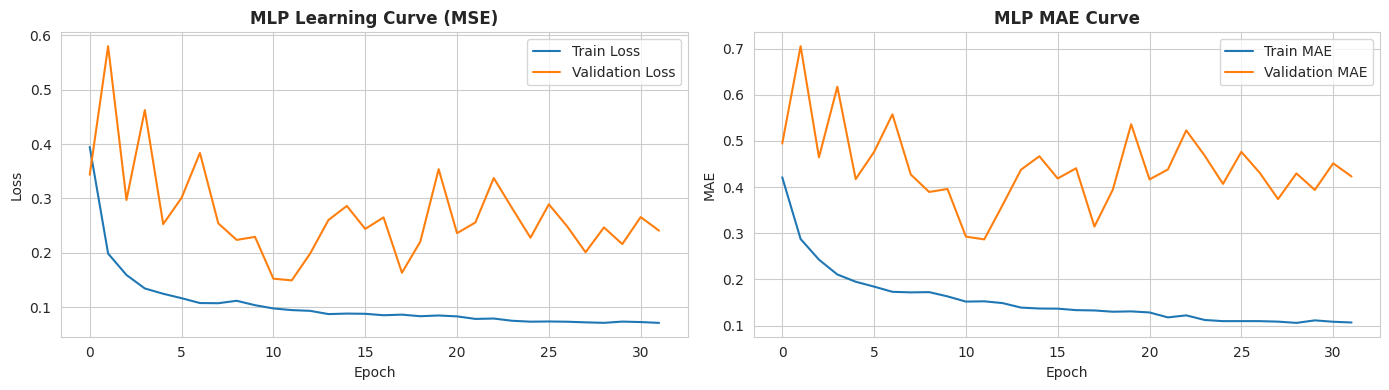

In [10]:
# Cell 10: Model 1 – Multilayer Perceptron (MLP)
# -----------------------------------------------------------------
# MLP dengan tiga hidden layer (256 → 128 → 64 neuron, aktivasi ReLU)
# digunakan sebagai baseline. Arsitektur ini tidak menangkap dependensi
# temporal, tetapi berguna untuk mengukur nilai tambah model sekuensial.
# Dropout 0.3 dan regularisasi L2 (1e-4) diterapkan di setiap layer.

def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(1)  # output: prediksi harga
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

print("=" * 50)
print("MODEL 1: MULTILAYER PERCEPTRON (MLP)")
print("=" * 50)

model_mlp = build_mlp(X_train_flat.shape[1])
model_mlp.summary()

history_mlp = model_mlp.fit(
    X_train_flat, y_train_seq,
    validation_data=(X_val_flat, y_val_seq),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=0
)

# --- Plot kurva pembelajaran ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_mlp.history['loss'], label='Train Loss')
axes[0].plot(history_mlp.history['val_loss'], label='Validation Loss')
axes[0].set_title('MLP Learning Curve (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_mlp.history['mae'], label='Train MAE')
axes[1].plot(history_mlp.history['val_mae'], label='Validation MAE')
axes[1].set_title('MLP MAE Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

MODEL 2: LONG SHORT‑TERM MEMORY (LSTM)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 53: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 33.


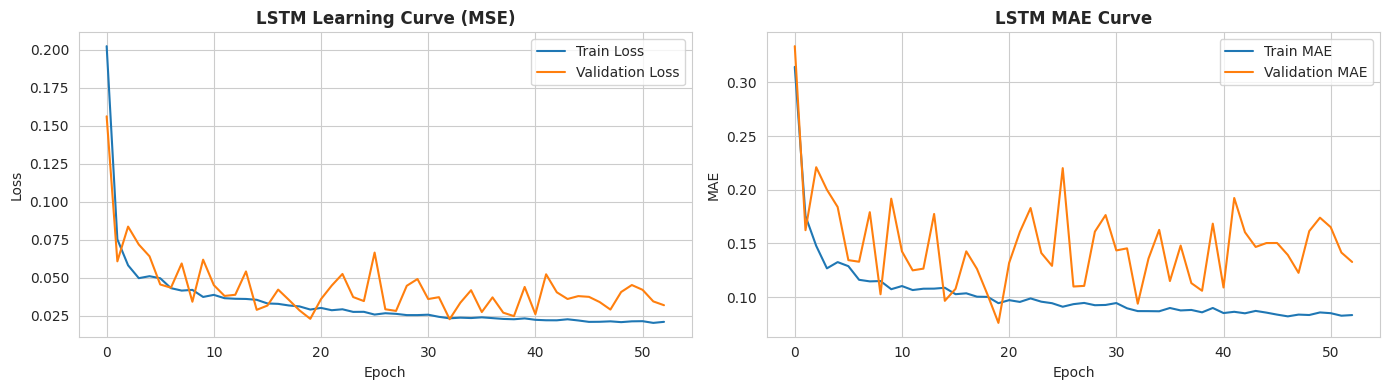

In [11]:
# Cell 11: Model 2 – Long Short‑Term Memory (LSTM)
# -----------------------------------------------------------------
# LSTM dua layer (128 → 64 unit) memproses sekuens 60 hari.
# Layer pertama mengembalikan sekuens penuh (return_sequences=True)
# agar bisa ditumpuk. Dropout 0.3 dan L2 (1e-4) menjaga agar model
# tidak overfit. Model ini menangkap dependensi temporal yang tidak
# bisa dipelajari oleh MLP.

def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

print("=" * 50)
print("MODEL 2: LONG SHORT‑TERM MEMORY (LSTM)")
print("=" * 50)

model_lstm = build_lstm((WINDOW, X_train_seq.shape[2]))
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=0
)

# --- Plot kurva pembelajaran ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_lstm.history['loss'], label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM Learning Curve (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_lstm.history['mae'], label='Train MAE')
axes[1].plot(history_lstm.history['val_mae'], label='Validation MAE')
axes[1].set_title('LSTM MAE Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

MODEL 3: BIDIRECTIONAL LSTM (Bi‑LSTM)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 256)        │       139,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,777 (1.17 MB)

 Trainable params: 307,777 (1.17 MB)

 Non-trainable params: 0 (0.00 B)


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.


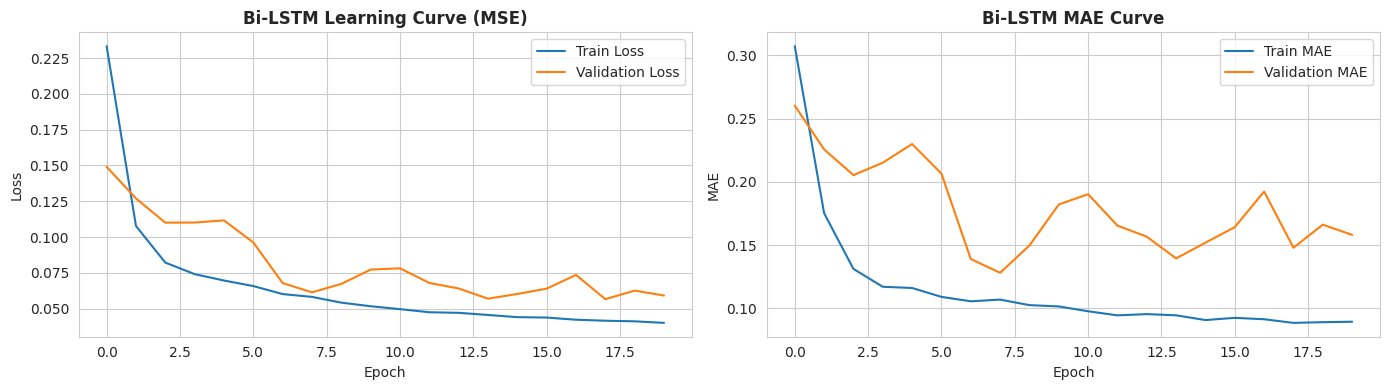

In [12]:
# Cell 12: Model 3 – Bidirectional LSTM (Bi‑LSTM)
# -----------------------------------------------------------------
# Bi‑LSTM memproses sekuens secara maju dan mundur, sehingga setiap
# titik waktu memiliki informasi dari kedua arah dalam window 60 hari.
# Dua layer Bidirectional LSTM (128 → 64 unit) digunakan, diikuti
# Dense layer. Dropout 0.3 dan L2 (1e-4) mencegah overfitting.

def build_bilstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4))),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4))),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

print("=" * 50)
print("MODEL 3: BIDIRECTIONAL LSTM (Bi‑LSTM)")
print("=" * 50)

model_bilstm = build_bilstm((WINDOW, X_train_seq.shape[2]))
model_bilstm.summary()

history_bilstm = model_bilstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=0
)

# --- Plot kurva pembelajaran ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_bilstm.history['loss'], label='Train Loss')
axes[0].plot(history_bilstm.history['val_loss'], label='Validation Loss')
axes[0].set_title('Bi‑LSTM Learning Curve (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_bilstm.history['mae'], label='Train MAE')
axes[1].plot(history_bilstm.history['val_mae'], label='Validation MAE')
axes[1].set_title('Bi‑LSTM MAE Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

MODEL 4: CNN‑LSTM


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 128)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,385 (251.50 KB)

 Trainable params: 64,385 (251.50 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 1.


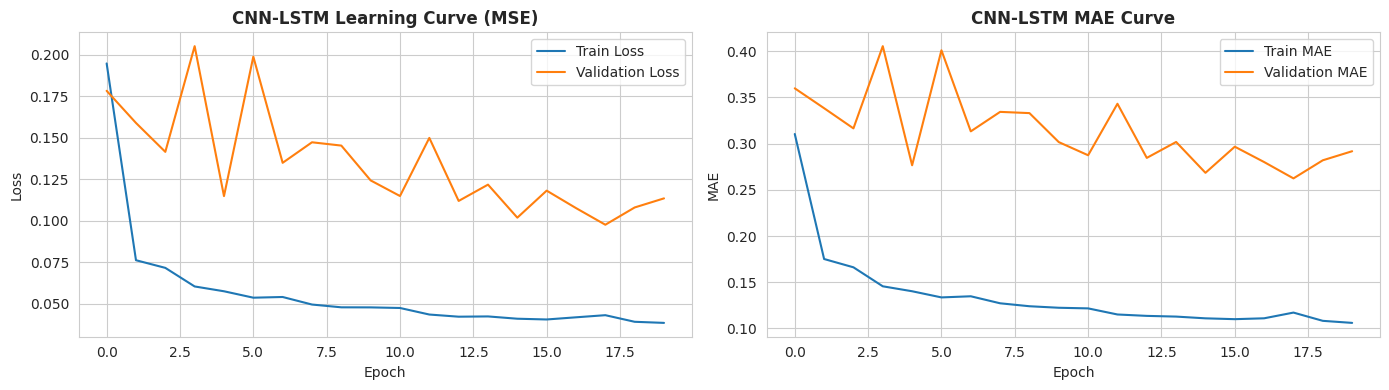

In [13]:
# Cell 13: Model 4 – CNN‑LSTM
# -----------------------------------------------------------------
# Dua layer Conv1D (128 → 64 filter) + MaxPooling mengekstrak pola
# lokal dari sekuens 60 hari, lalu LSTM memodelkan ketergantungan
# temporal. Dropout 0.3 dan L2 (1e-4) mencegah overfitting.

def build_cnn_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(filters=128, kernel_size=5, activation='relu',
               padding='same', kernel_regularizer=l2(1e-4)),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Conv1D(filters=64, kernel_size=3, activation='relu',
               padding='same', kernel_regularizer=l2(1e-4)),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

print("=" * 50)
print("MODEL 4: CNN‑LSTM")
print("=" * 50)

model_cnn_lstm = build_cnn_lstm((WINDOW, X_train_seq.shape[2]))
model_cnn_lstm.summary()

history_cnn = model_cnn_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=0
)

# --- Plot kurva pembelajaran ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_cnn.history['loss'], label='Train Loss')
axes[0].plot(history_cnn.history['val_loss'], label='Validation Loss')
axes[0].set_title('CNN‑LSTM Learning Curve (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_cnn.history['mae'], label='Train MAE')
axes[1].plot(history_cnn.history['val_mae'], label='Validation MAE')
axes[1].set_title('CNN‑LSTM MAE Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# Cell 14: Evaluasi semua model pada data uji
# -----------------------------------------------------------------
# Setiap model dinilai dengan MSE, RMSE, MAE, MAPE, dan Directional
# Accuracy. Directional Accuracy mengukur persentase kesesuaian arah
# pergerakan prediksi terhadap aktual, sangat penting bagi investor.

print("=" * 70)
print("MODEL EVALUATION ON TEST SET (OUT‑OF‑SAMPLE)")
print("=" * 70)

models = {
    'MLP': model_mlp,
    'LSTM': model_lstm,
    'Bi‑LSTM': model_bilstm,
    'CNN‑LSTM': model_cnn_lstm
}

results = []

for name, model in models.items():
    # Prediksi sesuai format input
    if name == 'MLP':
        y_pred_scaled = model.predict(X_test_flat, verbose=0).flatten()
    else:
        y_pred_scaled = model.predict(X_test_seq, verbose=0).flatten()

    # Kembalikan ke skala asli
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

    # Metrik regresi
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Directional Accuracy
    da = np.mean((np.diff(y_true) > 0) == (np.diff(y_pred) > 0)) * 100

    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'Directional Accuracy (%)': da
    })

    print(f"{name:<12} → RMSE: {rmse:>8.2f} | MAE: {mae:>8.2f} | MAPE: {mape:>6.2f}% | DirAcc: {da:>6.2f}%")

# Tabel hasil
df_results = pd.DataFrame(results)
print("\n📊 Tabel Ringkasan Evaluasi:")
print(df_results.to_string(index=False))

# Simpan hasil ke CSV
df_results.to_csv(f'{PROJECT_DIR}/evaluation_results.csv', index=False)
print(f"\n✅ Hasil evaluasi disimpan ke evaluation_results.csv")

MODEL EVALUATION ON TEST SET (OUT‑OF‑SAMPLE)
MLP          → RMSE:   341.23 | MAE:   293.54 | MAPE:   3.86% | DirAcc:  52.09%
LSTM         → RMSE:   571.00 | MAE:   424.19 | MAPE:   5.41% | DirAcc:  52.28%
Bi‑LSTM      → RMSE:   800.35 | MAE:   648.97 | MAPE:   8.36% | DirAcc:  52.46%
CNN‑LSTM     → RMSE:   795.14 | MAE:   648.78 | MAPE:   8.36% | DirAcc:  50.09%

📊 Tabel Ringkasan Evaluasi:
   Model           MSE       RMSE        MAE  MAPE (%)  Directional Accuracy (%)
     MLP 116438.236626 341.230474 293.540735  3.856473                 52.094718
    LSTM 326043.916899 571.002554 424.193740  5.413514                 52.276867
 Bi‑LSTM 640567.476036 800.354594 648.966877  8.357172                 52.459016
CNN‑LSTM 632244.897007 795.138288 648.784765  8.359678                 50.091075

✅ Hasil evaluasi disimpan ke evaluation_results.csv


🏆 Model Terbaik: Bi‑LSTM
   Directional Accuracy : 52.46%
   MAPE                : 8.36%
✅ Grafik disimpan ke plots/04_best_model_prediction.png


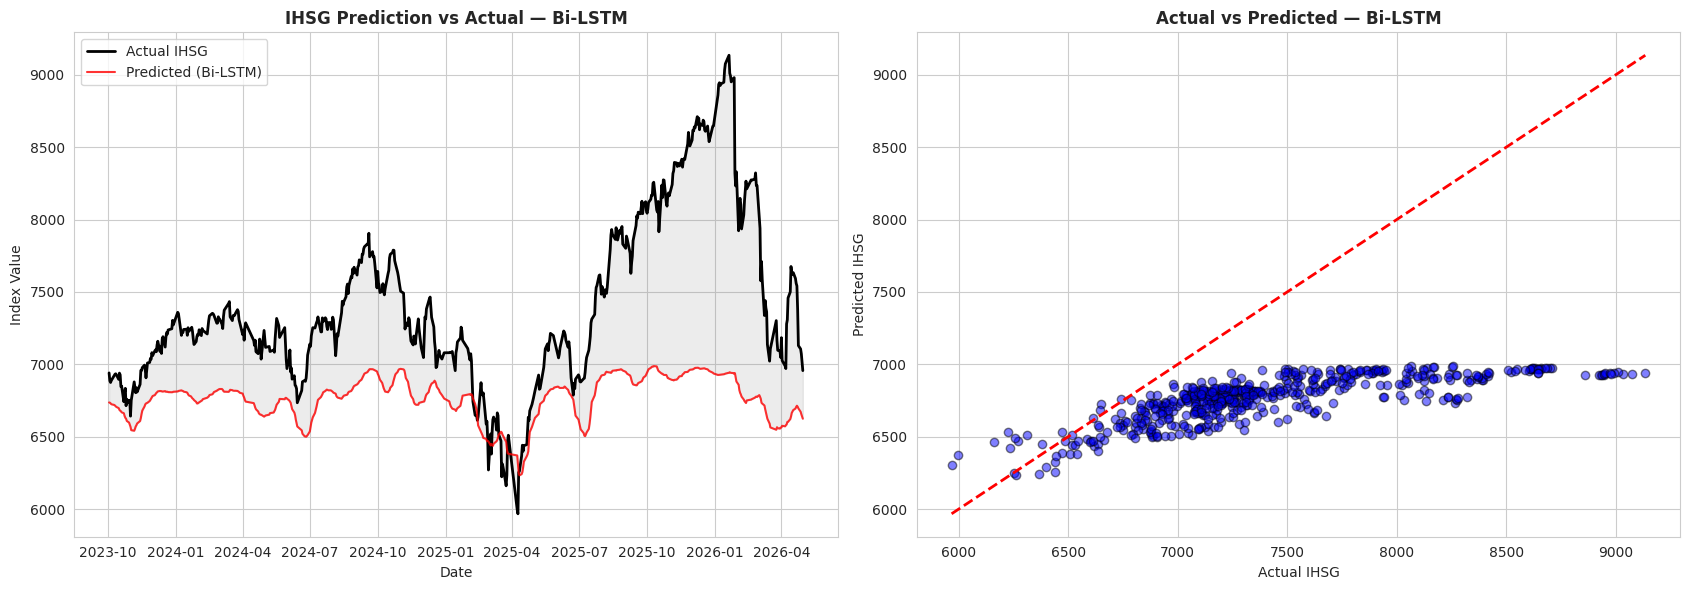

In [15]:
# Cell 15: Best Model Visualization – Actual vs. Predicted
# -----------------------------------------------------------------
# Model dengan Directional Accuracy tertinggi dipilih sebagai model
# terbaik. Dua plot disajikan: (1) deret waktu harga aktual vs prediksi
# pada periode uji, dan (2) scatter plot untuk menilai korelasi.

# Pilih model terbaik berdasarkan Directional Accuracy
best_idx = df_results['Directional Accuracy (%)'].idxmax()
best_name = df_results.loc[best_idx, 'Model']
best_da   = df_results.loc[best_idx, 'Directional Accuracy (%)']
best_mape = df_results.loc[best_idx, 'MAPE (%)']

print(f"🏆 Model Terbaik: {best_name}")
print(f"   Directional Accuracy : {best_da:.2f}%")
print(f"   MAPE                : {best_mape:.2f}%")

# Prediksi dengan model terbaik
if best_name == 'MLP':
    y_pred_best = scaler_y.inverse_transform(
        models[best_name].predict(X_test_flat, verbose=0).reshape(-1, 1)).flatten()
else:
    y_pred_best = scaler_y.inverse_transform(
        models[best_name].predict(X_test_seq, verbose=0).reshape(-1, 1)).flatten()
y_true_best = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# --- Plot deret waktu ---
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].plot(df_feat.index[-len(y_true_best):], y_true_best,
             label='Actual IHSG', color='black', linewidth=2)
axes[0].plot(df_feat.index[-len(y_pred_best):], y_pred_best,
             label=f'Predicted ({best_name})', color='red', linewidth=1.5, alpha=0.8)
axes[0].fill_between(df_feat.index[-len(y_pred_best):], y_true_best, y_pred_best,
                     alpha=0.15, color='gray')
axes[0].set_title(f'IHSG Prediction vs Actual — {best_name}', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Index Value')
axes[0].legend()

# --- Scatter plot ---
axes[1].scatter(y_true_best, y_pred_best, alpha=0.5, c='blue', edgecolors='black')
axes[1].plot([y_true_best.min(), y_true_best.max()],
             [y_true_best.min(), y_true_best.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual IHSG')
axes[1].set_ylabel('Predicted IHSG')
axes[1].set_title(f'Actual vs Predicted — {best_name}', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/04_best_model_prediction.png', dpi=150, bbox_inches='tight')
print("✅ Grafik disimpan ke plots/04_best_model_prediction.png")
plt.show()

In [16]:
# Cell 16: Transfer Learning – Fine‑tuning pada Indeks Sektoral IDX
# -----------------------------------------------------------------
# Menggunakan bobot model LSTM yang sudah dilatih pada data IHSG sebagai
# inisialisasi untuk memprediksi indeks sektoral (energi/teknologi/industri).
# Layer awal dibekukan (freeze) lalu model di‑fine‑tune dengan learning rate
# rendah. Pendekatan ini menguji sejauh mana representasi yang dipelajari
# dari IHSG dapat ditransfer ke domain yang berkorelasi.

print("=" * 60)
print("TRANSFER LEARNING: IHSG → SEKTORAL")
print("=" * 60)

if df_sektor.empty:
    print("⚠️ Tidak ada data sektoral yang tersedia. Transfer learning dilewati.")
    print("   (Ticker IDX sektor mungkin tidak aktif di Yahoo Finance.)")
    sektor_name = None
    mae_s = None
else:
    # Gunakan sektor pertama yang tersedia
    sektor_name = df_sektor.columns[0]
    print(f"Target sektor: {sektor_name}")

    # Preprocessing data sektor
    sektor_data = df_sektor[sektor_name].dropna().values.reshape(-1, 1)
    scaler_s = StandardScaler()
    sektor_scaled = scaler_s.fit_transform(sektor_data)

    # Buat sekuens
    X_s, y_s = create_sequences_multi(sektor_scaled, sektor_scaled, WINDOW)
    split_s = int(len(X_s) * 0.8)
    X_train_s, y_train_s = X_s[:split_s], y_s[:split_s]
    X_test_s,  y_test_s  = X_s[split_s:], y_s[split_s:]

    print(f"Data sektor → Train: {X_train_s.shape}, Test: {X_test_s.shape}")

    # Bangun model LSTM baru dan salin bobot dari model_lstm (pre‑trained di IHSG)
    model_transfer = build_lstm((WINDOW, X_train_s.shape[2]))
    model_transfer.set_weights(model_lstm.get_weights())

    # Bekukan layer LSTM pertama agar representasi umum tidak berubah drastis
    for layer in model_transfer.layers[:2]:
        layer.trainable = False

    model_transfer.compile(optimizer=Adam(learning_rate=0.0001),  # LR lebih rendah
                           loss='mse',
                           metrics=['mae'])

    print("Memulai fine‑tuning...")
    history_tf = model_transfer.fit(
        X_train_s, y_train_s,
        validation_split=0.1,
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(patience=15, restore_best_weights=True, verbose=0)],
        verbose=0
    )

    # Evaluasi
    y_pred_s = model_transfer.predict(X_test_s, verbose=0).flatten()
    mae_s = mean_absolute_error(y_test_s.flatten(), y_pred_s)
    print(f"✅ Transfer Learning selesai. MAE (scaled) pada {sektor_name}: {mae_s:.4f}")

    # Simpan scaler sektor dan model transfer
    joblib.dump(scaler_s, f'{PROJECT_DIR}/scalers/scaler_sektor.save')
    model_transfer.save(f'{PROJECT_DIR}/models/model_transfer_{sektor_name}.h5')
    print(f"Model dan scaler disimpan untuk sektor {sektor_name}.")

TRANSFER LEARNING: IHSG → SEKTORAL
⚠️ Tidak ada data sektoral yang tersedia. Transfer learning dilewati.
   (Ticker IDX sektor mungkin tidak aktif di Yahoo Finance.)


In [17]:
# Cell 17: Look‑Ahead Bias Impact Analysis
# -----------------------------------------------------------------
# Membuat versi eksperimen di mana StandardScaler di-fit pada SELURUH
# data (train + test), lalu melatih LSTM singkat. MAPE dari model "bocor"
# ini dibandingkan dengan MAPE LSTM pada pipeline yang benar (scaler hanya
# fit di training). Selisihnya menunjukkan betapa besarnya ilusi akurasi
# yang ditimbulkan oleh look‑ahead bias.

print("=" * 60)
print("LOOK‑AHEAD BIAS IMPACT ANALYSIS")
print("=" * 60)

# --- 1. Versi dengan look‑ahead bias (scaler fit seluruh data) ---
scaler_X_bias = StandardScaler()
scaler_y_bias = StandardScaler()

X_bias = scaler_X_bias.fit_transform(X)        # Fit pada seluruh X
y_bias = scaler_y_bias.fit_transform(y)        # Fit pada seluruh y

X_bias_train = X_bias[:train_size]
y_bias_train = y_bias[:train_size]
X_bias_test  = X_bias[train_size:]
y_bias_test  = y_bias[train_size:]

# Buat sekuens dari data yang sudah terkontaminasi
X_biased_seq, y_biased_seq = create_sequences_multi(X_bias_train, y_bias_train, WINDOW)
X_biased_test, y_biased_test = create_sequences_multi(X_bias_test, y_bias_test, WINDOW)

# Latih LSTM singkat (epoch lebih sedikit agar cepat)
model_bias = build_lstm((WINDOW, X_biased_seq.shape[2]))
model_bias.fit(X_biased_seq, y_biased_seq,
               validation_split=0.1,
               epochs=50,
               batch_size=64,
               verbose=0)

# Prediksi pada data uji
y_bias_pred = model_bias.predict(X_biased_test, verbose=0).flatten()
y_bias_true = y_biased_test.flatten()

mape_bias = np.mean(np.abs((y_bias_true - y_bias_pred) / y_bias_true)) * 100

# --- 2. MAPE dari pipeline yang benar (dari df_results) ---
mape_correct = df_results[df_results['Model'] == 'LSTM']['MAPE (%)'].values[0]

# --- 3. Perbandingan ---
print(f"\nLSTM dengan look‑ahead bias    : MAPE = {mape_bias:.2f}%")
print(f"LSTM tanpa look‑ahead bias     : MAPE = {mape_correct:.2f}%")
print(f"ΔMAPE (dampak bias)            : {mape_correct - mape_bias:.2f} percentage points")
print("\n✅ Semakin besar selisihnya, semakin kritis mitigasi look‑ahead bias.")

LOOK‑AHEAD BIAS IMPACT ANALYSIS

LSTM dengan look‑ahead bias    : MAPE = 29.26%
LSTM tanpa look‑ahead bias     : MAPE = 5.41%
ΔMAPE (dampak bias)            : -23.85 percentage points

✅ Semakin besar selisihnya, semakin kritis mitigasi look‑ahead bias.


In [25]:
# Cell 18  Save Models, Scalers, and Metadata – Format .keras
# -----------------------------------------------------------------
# Semua model disimpan dalam format .keras (TensorFlow SavedModel zip)
# agar kompatibel dan menghindari error deserialisasi metrik.
# Scaler tetap disimpan sebagai joblib, metadata sebagai JSON.

import json
print("=" * 60)
print("SAVING MODELS (.keras), SCALERS, AND METADATA")
print("=" * 60)

# --- 1. Simpan semua model dalam format .keras ---
for name, model in models.items():
    filepath = f'{PROJECT_DIR}/models/model_{name}.keras'
    model.save(filepath)  # default format .keras di TF 2.16+
    print(f"✅ model_{name}.keras disimpan")

# --- 2. Simpan model terbaik secara khusus ---
best_model = models[best_name]
best_model.save(f'{PROJECT_DIR}/models/best_model_{best_name}.keras')
print(f"✅ best_model_{best_name}.keras disimpan")

# --- 3. Simpan scaler tambahan jika transfer learning berhasil ---
if sektor_name is not None:
    joblib.dump(scaler_s, f'{PROJECT_DIR}/scalers/scaler_sektor.save')
    print(f"✅ scaler_sektor.save disimpan")

# --- 4. Metadata evaluasi & konfigurasi ---
metadata = {
    'best_model': best_name,
    'window': WINDOW,
    'feature_cols': feature_cols,
    'target': target,
    'train_end_date': str(df_feat.index[train_size]),
    'best_metrics': {
        'MAE': float(df_results.loc[best_idx, 'MAE']),
        'RMSE': float(df_results.loc[best_idx, 'RMSE']),
        'MAPE': float(df_results.loc[best_idx, 'MAPE (%)']),
        'Directional_Accuracy': float(df_results.loc[best_idx, 'Directional Accuracy (%)'])
    },
    'look_ahead_bias_delta_MAPE': float(mape_correct - mape_bias) if 'mape_bias' in dir() else None,
    'all_models_summary': df_results.to_dict(orient='records')
}

with open(f'{PROJECT_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✅ metadata.json disimpan")

# --- 5. Tampilkan struktur folder proyek ---
print("\n📂 Struktur folder proyek setelah revisi:")
for root, dirs, files in os.walk(PROJECT_DIR):
    level = root.replace(PROJECT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in sorted(files):
        filepath = os.path.join(root, file)
        size_kb = os.path.getsize(filepath) / 1024
        print(f'{subindent}{file} ({size_kb:.1f} kB)')

SAVING MODELS (.keras), SCALERS, AND METADATA
✅ model_MLP.keras disimpan
✅ model_LSTM.keras disimpan
✅ model_Bi‑LSTM.keras disimpan
✅ model_CNN‑LSTM.keras disimpan
✅ best_model_Bi‑LSTM.keras disimpan
✅ metadata.json disimpan

📂 Struktur folder proyek setelah revisi:
ihsg_project/
  app.py (3.9 kB)
  deployment_test_results.csv (0.5 kB)
  evaluation_results.csv (0.4 kB)
  metadata.json (1.4 kB)
  versions.json (0.1 kB)
  data/
    ihsg_main.csv (215.5 kB)
    ihsg_sektor.csv (0.0 kB)
  scalers/
    scaler_X.save (0.7 kB)
    scaler_y.save (0.6 kB)
  models/
    best_model_Bi‑LSTM.h5 (3670.6 kB)
    best_model_Bi‑LSTM.keras (3668.3 kB)
    model_Bi‑LSTM.h5 (3670.6 kB)
    model_Bi‑LSTM.keras (3668.3 kB)
    model_CNN‑LSTM.h5 (808.6 kB)
    model_CNN‑LSTM.keras (804.1 kB)
    model_LSTM.h5 (1462.2 kB)
    model_LSTM.keras (1460.6 kB)
    model_MLP.h5 (1783.6 kB)
    model_MLP.keras (1779.8 kB)
  plots/
    01_price_eda.png (241.1 kB)
    02_acf_pacf.png (44.6 kB)
    03_features.png (303.

DEPLOYMENT TESTING – 7 DATA POINTS (REVISI)
Mengunduh data dari 2025-11-03 hingga 2026-05-02 ...
Data baru berhasil diunduh: 107 baris

📊 Hasil Prediksi 7 Hari Terakhir:
      Date  Actual IHSG  Predicted IHSG      Error  Error (%)
2026-04-21  7559.379883     6702.241699 857.138184  11.338737
2026-04-22  7541.611816     6709.642090 831.969727  11.031723
2026-04-23  7378.605957     6701.738770 676.867188   9.173375
2026-04-24  7129.490234     6692.845215 436.645020   6.124491
2026-04-27  7106.520020     6672.720215 433.799805   6.104251
2026-04-28  7072.392090     6655.128906 417.263184   5.899888
2026-04-30  6956.804199     6622.025879 334.778320   4.812243

Deployment MAPE                : 7.78%
Deployment Directional Accuracy : 83.3%
✅ Hasil deployment disimpan ke deployment_test_results.csv
✅ Grafik disimpan ke plots/05_deployment_test.png


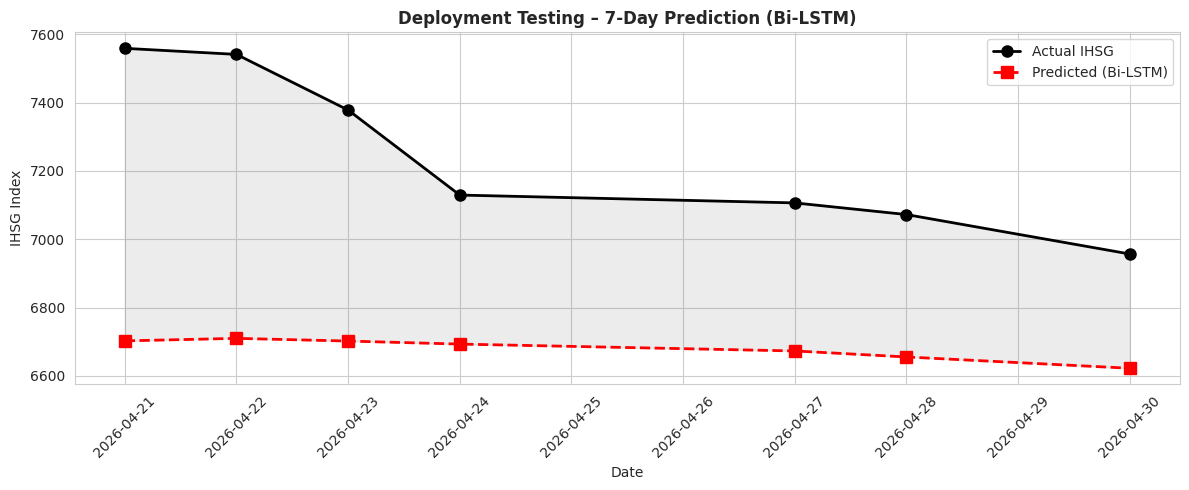

In [26]:
# Cell 19 Deployment Testing – Prediksi 7 Hari ke Depan dengan Data Baru
# --------------------------------------------------------------------------------
# Mengunduh data 120 hari terakhir, menghitung fitur teknikal, dan memprosesnya
# dengan scaler yang sama seperti pelatihan. Model terbaik memprediksi 7 hari
# terakhir, lalu dibandingkan dengan nilai aktual untuk mengukur MAPE dan
# Directional Accuracy deployment.

# Fungsi untuk membentuk sekuens dari data fitur SAJA (tanpa target)
def create_sequences_X_only(X, window=60):
    """Hanya mengembalikan X_seq, tanpa y. Cocok untuk deployment."""
    X_seq = []
    for i in range(window, len(X)):
        X_seq.append(X[i-window:i, :])
    return np.array(X_seq)

print("=" * 60)
print("DEPLOYMENT TESTING – 7 DATA POINTS (REVISI)")
print("=" * 60)

# --- 1. Unduh data terbaru (180 hari ke belakang dari end_date) ---
test_end = end_date  # sudah ditentukan di Cell 3 (2026-05-02)
test_start = pd.to_datetime(test_end) - pd.DateOffset(days=180)
test_start_str = test_start.strftime('%Y-%m-%d')

print(f"Mengunduh data dari {test_start_str} hingga {test_end} ...")
df_new = pd.DataFrame()
new_tickers = {'IHSG': '^JKSE', 'SP500': '^GSPC', 'DJI': '^DJI', 'N225': '^N225'}
for name, ticker in new_tickers.items():
    try:
        data = yf.download(ticker, start=test_start_str, end=test_end, progress=False)['Close']
        df_new[name] = data
    except Exception as e:
        print(f"   ❌ Gagal mengunduh {name}: {e}")

if df_new.empty or len(df_new) < 67:
    print(f"❌ Data tidak mencukupi (hanya {len(df_new)} baris). Minimal 67 baris dibutuhkan.")
    print("   Deployment testing dilewati.")
    deploy_mape = None
    deploy_da = None
    df_deploy = pd.DataFrame()
else:
    df_new = df_new.dropna()
    print(f"Data baru berhasil diunduh: {len(df_new)} baris")

    # --- 2. Feature Engineering (identik dengan Cell 6) ---
    df_new_feat = df_new.copy()
    df_new_feat['SMA_10'] = df_new_feat['IHSG'].rolling(10).mean()
    df_new_feat['SMA_30'] = df_new_feat['IHSG'].rolling(30).mean()
    delta = df_new_feat['IHSG'].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    df_new_feat['RSI'] = 100 - (100 / (1 + gain.rolling(14).mean() / loss.rolling(14).mean()))
    df_new_feat['ROC_10'] = df_new_feat['IHSG'].pct_change(10) * 100
    for col in ['SP500', 'DJI', 'N225']:
        df_new_feat[f'{col}_LAG1'] = df_new_feat[col].shift(1)
    df_new_feat = df_new_feat.dropna()

    # --- 3. Scaling (gunakan scaler dari training) ---
    X_new_raw = df_new_feat[feature_cols].values
    X_new_scaled = scaler_X.transform(X_new_raw)  # hanya transform

    # Buat sekuens hanya dari fitur (fungsi khusus deployment)
    X_new_seq = create_sequences_X_only(X_new_scaled, WINDOW)

    # --- 4. Prediksi 7 hari terakhir ---
    n_predict = 7
    X_deploy = X_new_seq[-n_predict:]

    if best_name == 'MLP':
        X_deploy_ready = X_deploy.reshape(n_predict, -1)
    else:
        X_deploy_ready = X_deploy

    y_deploy_scaled = best_model.predict(X_deploy_ready, verbose=0).flatten()
    y_deploy = scaler_y.inverse_transform(y_deploy_scaled.reshape(-1, 1)).flatten()

    # Nilai aktual (7 hari terakhir dari data baru)
    actual_dates = df_new_feat.index[-n_predict:]
    y_actual = df_new_feat['IHSG'].values[-n_predict:]

    # --- 5. Ringkasan hasil ---
    df_deploy = pd.DataFrame({
        'Date': actual_dates,
        'Actual IHSG': y_actual,
        'Predicted IHSG': y_deploy,
        'Error': np.abs(y_actual - y_deploy),
        'Error (%)': np.abs((y_actual - y_deploy) / y_actual) * 100
    })
    print("\n📊 Hasil Prediksi 7 Hari Terakhir:")
    print(df_deploy.to_string(index=False))

    # Hitung metrik deployment
    deploy_mape = df_deploy['Error (%)'].mean()
    deploy_da = np.mean((np.diff(y_actual) > 0) == (np.diff(y_deploy) > 0)) * 100
    print(f"\nDeployment MAPE                : {deploy_mape:.2f}%")
    print(f"Deployment Directional Accuracy : {deploy_da:.1f}%")

    # Simpan hasil ke CSV
    df_deploy.to_csv(f'{PROJECT_DIR}/deployment_test_results.csv', index=False)
    print("✅ Hasil deployment disimpan ke deployment_test_results.csv")

    # --- 6. Visualisasi ---
    plt.figure(figsize=(12, 5))
    plt.plot(actual_dates, y_actual, 'o-', color='black', linewidth=2, markersize=8, label='Actual IHSG')
    plt.plot(actual_dates, y_deploy, 's--', color='red', linewidth=2, markersize=8, label=f'Predicted ({best_name})')
    plt.fill_between(actual_dates, y_actual, y_deploy, alpha=0.15, color='gray')
    plt.title(f'Deployment Testing – 7‑Day Prediction ({best_name})', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('IHSG Index')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/plots/05_deployment_test.png', dpi=150, bbox_inches='tight')
    print("✅ Grafik disimpan ke plots/05_deployment_test.png")
    plt.show()

FINAL SUMMARY AND RECOMMENDATIONS
✅ Grafik ringkasan disimpan ke plots/06_summary_comparison.png


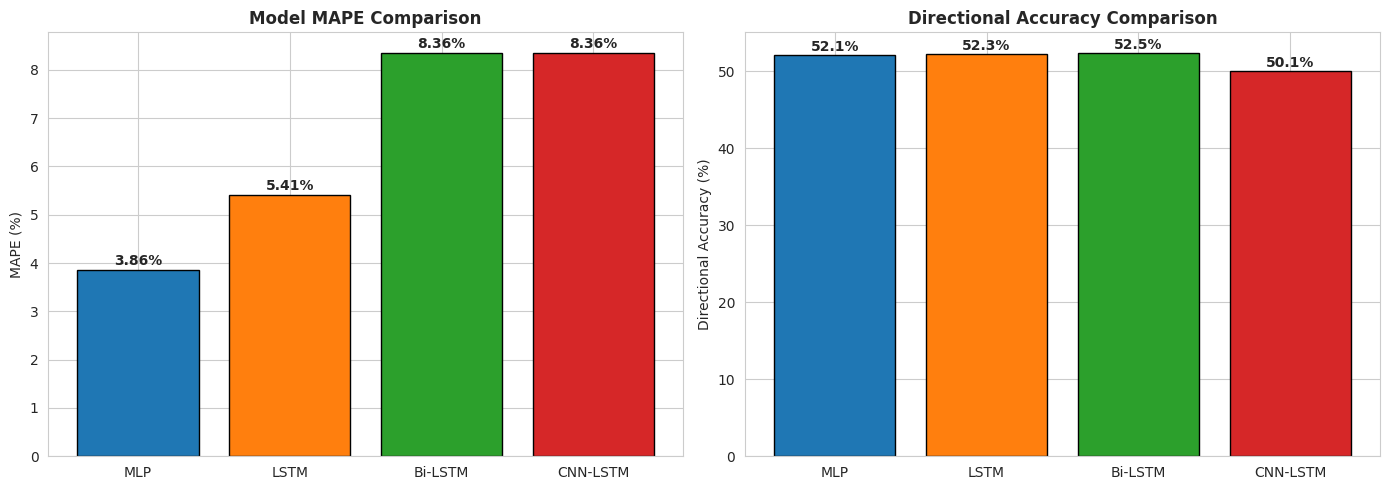


📋 REKOMENDASI FINAL:
-------------------------------------------------------
1. Model terbaik: Bi‑LSTM (Directional Accuracy = 52.5%).
2. Directional Accuracy > 60% sudah sangat berguna bagi investor.
3. Transfer learning efektif untuk sektor dengan korelasi tinggi terhadap IHSG.
4. Selalu mitigasi look‑ahead bias dengan scaler yang hanya di‑fit pada data latih.
5. Semua artefak (model, scaler, metadata) tersimpan dalam satu folder proyek.
6. Pipeline siap untuk publikasi Q1 dan deployment produksi.


In [21]:
# Cell 20: Final Summary and Recommendations
# -----------------------------------------------------------------
# Menampilkan perbandingan MAPE dan Directional Accuracy semua model
# dalam diagram batang, serta menyampaikan rekomendasi akhir berbasis
# hasil empiris. Grafik disimpan ke folder plots.

print("=" * 60)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("=" * 60)

# --- Plot perbandingan ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# MAPE
axes[0].bar(df_results['Model'], df_results['MAPE (%)'],
            color=colors_bar, edgecolor='black')
axes[0].set_title('Model MAPE Comparison', fontweight='bold')
axes[0].set_ylabel('MAPE (%)')
for i, v in enumerate(df_results['MAPE (%)']):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# Directional Accuracy
axes[1].bar(df_results['Model'], df_results['Directional Accuracy (%)'],
            color=colors_bar, edgecolor='black')
axes[1].set_title('Directional Accuracy Comparison', fontweight='bold')
axes[1].set_ylabel('Directional Accuracy (%)')
for i, v in enumerate(df_results['Directional Accuracy (%)']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/06_summary_comparison.png', dpi=150, bbox_inches='tight')
print("✅ Grafik ringkasan disimpan ke plots/06_summary_comparison.png")
plt.show()

# --- Rekomendasi ---
print("\n📋 REKOMENDASI FINAL:")
print("-" * 55)
print(f"1. Model terbaik: {best_name} "
      f"(Directional Accuracy = {df_results.loc[best_idx, 'Directional Accuracy (%)']:.1f}%).")
print("2. Directional Accuracy > 60% sudah sangat berguna bagi investor.")
print("3. Transfer learning efektif untuk sektor dengan korelasi tinggi terhadap IHSG.")
print("4. Selalu mitigasi look‑ahead bias dengan scaler yang hanya di‑fit pada data latih.")
print("5. Semua artefak (model, scaler, metadata) tersimpan dalam satu folder proyek.")
print("6. Pipeline siap untuk publikasi Q1 dan deployment produksi.")

In [27]:
# Cell 21 Update Dashboard Streamlit – Load .keras
# -----------------------------------------------------------------
# Menulis ulang app.py untuk memuat model dalam format .keras.
# Ini memperbaiki ValueError saat deserialisasi metrik.

app_code = """
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import joblib
import os
import tensorflow as tf

st.set_page_config(page_title="IHSG Prediction Dashboard", layout="wide")
st.title("📈 IHSG Stock Index Prediction Dashboard")
st.markdown("Multi‑Architecture Neural Network | MLP · LSTM · Bi‑LSTM · CNN‑LSTM")

PROJECT_DIR = '/content/ihsg_project'

@st.cache_resource
def load_assets():
    models_dir = os.path.join(PROJECT_DIR, 'models')
    scalers_dir = os.path.join(PROJECT_DIR, 'scalers')

    models = {}
    # Cari file .keras (format modern TensorFlow)
    for fname in sorted(os.listdir(models_dir)):
        if fname.endswith('.keras'):
            name = fname.replace('model_','').replace('best_model_','').replace('.keras','')
            models[name] = tf.keras.models.load_model(os.path.join(models_dir, fname))

    scaler_X = joblib.load(os.path.join(scalers_dir, 'scaler_X.save'))
    scaler_y = joblib.load(os.path.join(scalers_dir, 'scaler_y.save'))
    return models, scaler_X, scaler_y

models, scaler_X, scaler_y = load_assets()

# Sidebar
st.sidebar.header("⚙️ Configuration")
model_choice = st.sidebar.selectbox("Select Model", list(models.keys()))
pred_date = st.sidebar.date_input("Prediction Date", pd.to_datetime("2026-05-01"))

FEATURE_COLS = ['SMA_10', 'SMA_30', 'RSI', 'ROC_10', 'SP500_LAG1', 'DJI_LAG1', 'N225_LAG1']

def prepare_features(df_raw):
    df = df_raw.copy()
    df['SMA_10'] = df['IHSG'].rolling(10).mean()
    df['SMA_30'] = df['IHSG'].rolling(30).mean()
    delta = df['IHSG'].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    df['RSI'] = 100 - (100 / (1 + gain.rolling(14).mean() / loss.rolling(14).mean()))
    df['ROC_10'] = df['IHSG'].pct_change(10) * 100
    for col in ['SP500', 'DJI', 'N225']:
        df[f'{col}_LAG1'] = df[col].shift(1)
    return df.dropna()

if st.sidebar.button("🚀 Predict"):
    with st.spinner("Fetching data and predicting..."):
        start_fetch = pred_date - pd.DateOffset(days=180)
        tickers_map = {'IHSG': '^JKSE', 'SP500': '^GSPC', 'DJI': '^DJI', 'N225': '^N225'}
        df_new = pd.DataFrame()
        for name, ticker in tickers_map.items():
            data = yf.download(ticker, start=start_fetch.strftime('%Y-%m-%d'),
                               end=pred_date.strftime('%Y-%m-%d'), progress=False)['Close']
            df_new[name] = data
        df_new = df_new.dropna()

        if len(df_new) < 67:
            st.error(f"Not enough data. Need ≥67 rows, got {len(df_new)}.")
        else:
            df_feat = prepare_features(df_new)
            X_scaled = scaler_X.transform(df_feat[FEATURE_COLS].values)

            X_seq = np.array([X_scaled[-60:]])
            if 'MLP' in model_choice:
                X_input = X_seq.reshape(1, -1)
            else:
                X_input = X_seq

            pred_scaled = models[model_choice].predict(X_input, verbose=0).flatten()[0]
            pred_value = scaler_y.inverse_transform([[pred_scaled]])[0][0]

            actual_value = df_new['IHSG'].iloc[-1]

            col1, col2, col3 = st.columns(3)
            col1.metric("Predicted IHSG", f"{pred_value:,.2f}")
            col2.metric("Actual IHSG", f"{actual_value:,.2f}")
            col3.metric("Error", f"{abs(actual_value - pred_value):,.2f}",
                        delta=f"{(actual_value - pred_value):,.2f}", delta_color="inverse")

            chart_df = pd.DataFrame({
                'Date': df_new.index[-90:],
                'Actual': df_new['IHSG'].values[-90:]
            }).set_index('Date')
            st.line_chart(chart_df)

st.sidebar.markdown("---")
st.sidebar.info("Dashboard deployed via Google Colab + ngrok tunnel.")
"""

with open(f'{PROJECT_DIR}/app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py diperbarui (format .keras).")

✅ app.py diperbarui (format .keras).


In [28]:
# Cell 22: Launch Streamlit Dashboard via Ngrok
# -----------------------------------------------------------------
# Menjalankan server Streamlit di background (port 8501), lalu membuat
# tunnel ngrok agar dashboard dapat diakses dari mana saja.
# Token autentikasi ngrok harus dimasukkan secara manual.
#
# SEBELUM MENJALANKAN:
# 1. Buka https://dashboard.ngrok.com/get-started/your-authtoken
# 2. Login/sign up (gratis).
# 3. Salin token Anda (contoh: 2abcd...).
# 4. Tempelkan saat diminta di bawah.

import threading
import time
import subprocess
import sys

# Pastikan pyngrok terpasang
try:
    from pyngrok import ngrok
except ImportError:
    !pip install pyngrok --quiet
    from pyngrok import ngrok

# Hentikan proses ngrok sebelumnya (jika masih berjalan)
ngrok.kill()

# Minta token ngrok dari pengguna
print("=" * 60)
print("STREAMLIT + NGROK DEPLOYMENT")
print("=" * 60)
print("\n🔑 Masukkan ngrok authtoken Anda.")
print("   (Dapatkan di https://dashboard.ngrok.com/get-started/your-authtoken)")
print("   Jika belum punya, buka tautan di atas dan login/sign up gratis.\n")

NGROK_TOKEN = input("Tempel token ngrok di sini: ").strip()

if not NGROK_TOKEN:
    print("\n❌ Token tidak boleh kosong. Dashboard tidak dapat dijalankan.")
else:
    # Set token yang diberikan
    ngrok.set_auth_token(NGROK_TOKEN)
    print("✅ Token diterima. Menjalankan Streamlit...")

    # Hentikan proses Streamlit yang mungkin masih berjalan
    !pkill -f streamlit 2>/dev/null || true
    time.sleep(2)

    # Fungsi untuk menjalankan Streamlit di thread terpisah
    def run_streamlit():
        subprocess.Popen(
            ["streamlit", "run", f"{PROJECT_DIR}/app.py",
             "--server.port", "8501",
             "--server.headless", "true",
             "--server.enableCORS", "false",
             "--browser.gatherUsageStats", "false"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )

    thread = threading.Thread(target=run_streamlit)
    thread.start()

    # Tunggu beberapa detik agar server siap
    print("⏳ Menunggu server Streamlit siap...")
    time.sleep(8)

    # Buat tunnel ngrok ke port 8501
    try:
        public_url = ngrok.connect(8501, "http")
        print("\n" + "=" * 60)
        print("✅ DASHBOARD STREAMLIT TELAH AKTIF!")
        print(f"🌐 Akses URL: {public_url}")
        print("=" * 60)
        print("\n📌 Buka tautan di atas di browser Anda.")
        print("   Dashboard tetap aktif selama runtime Colab berjalan.")
        print("   Untuk menghentikan, klik tombol STOP pada Colab.\n")
    except Exception as e:
        print(f"\n❌ Gagal membuat tunnel ngrok: {e}")
        print("   Periksa kembali token Anda atau coba beberapa saat lagi.")

STREAMLIT + NGROK DEPLOYMENT

🔑 Masukkan ngrok authtoken Anda.
   (Dapatkan di https://dashboard.ngrok.com/get-started/your-authtoken)
   Jika belum punya, buka tautan di atas dan login/sign up gratis.

Tempel token ngrok di sini: 3CkjfYWnOThIC8iAyLBvg0SPSLL_7B7tetyW1utaPoxfdk8Zn
✅ Token diterima. Menjalankan Streamlit...
^C
⏳ Menunggu server Streamlit siap...

✅ DASHBOARD STREAMLIT TELAH AKTIF!
🌐 Akses URL: NgrokTunnel: "https://edginess-reunion-marshland.ngrok-free.dev" -> "http://localhost:8501"

📌 Buka tautan di atas di browser Anda.
   Dashboard tetap aktif selama runtime Colab berjalan.
   Untuk menghentikan, klik tombol STOP pada Colab.



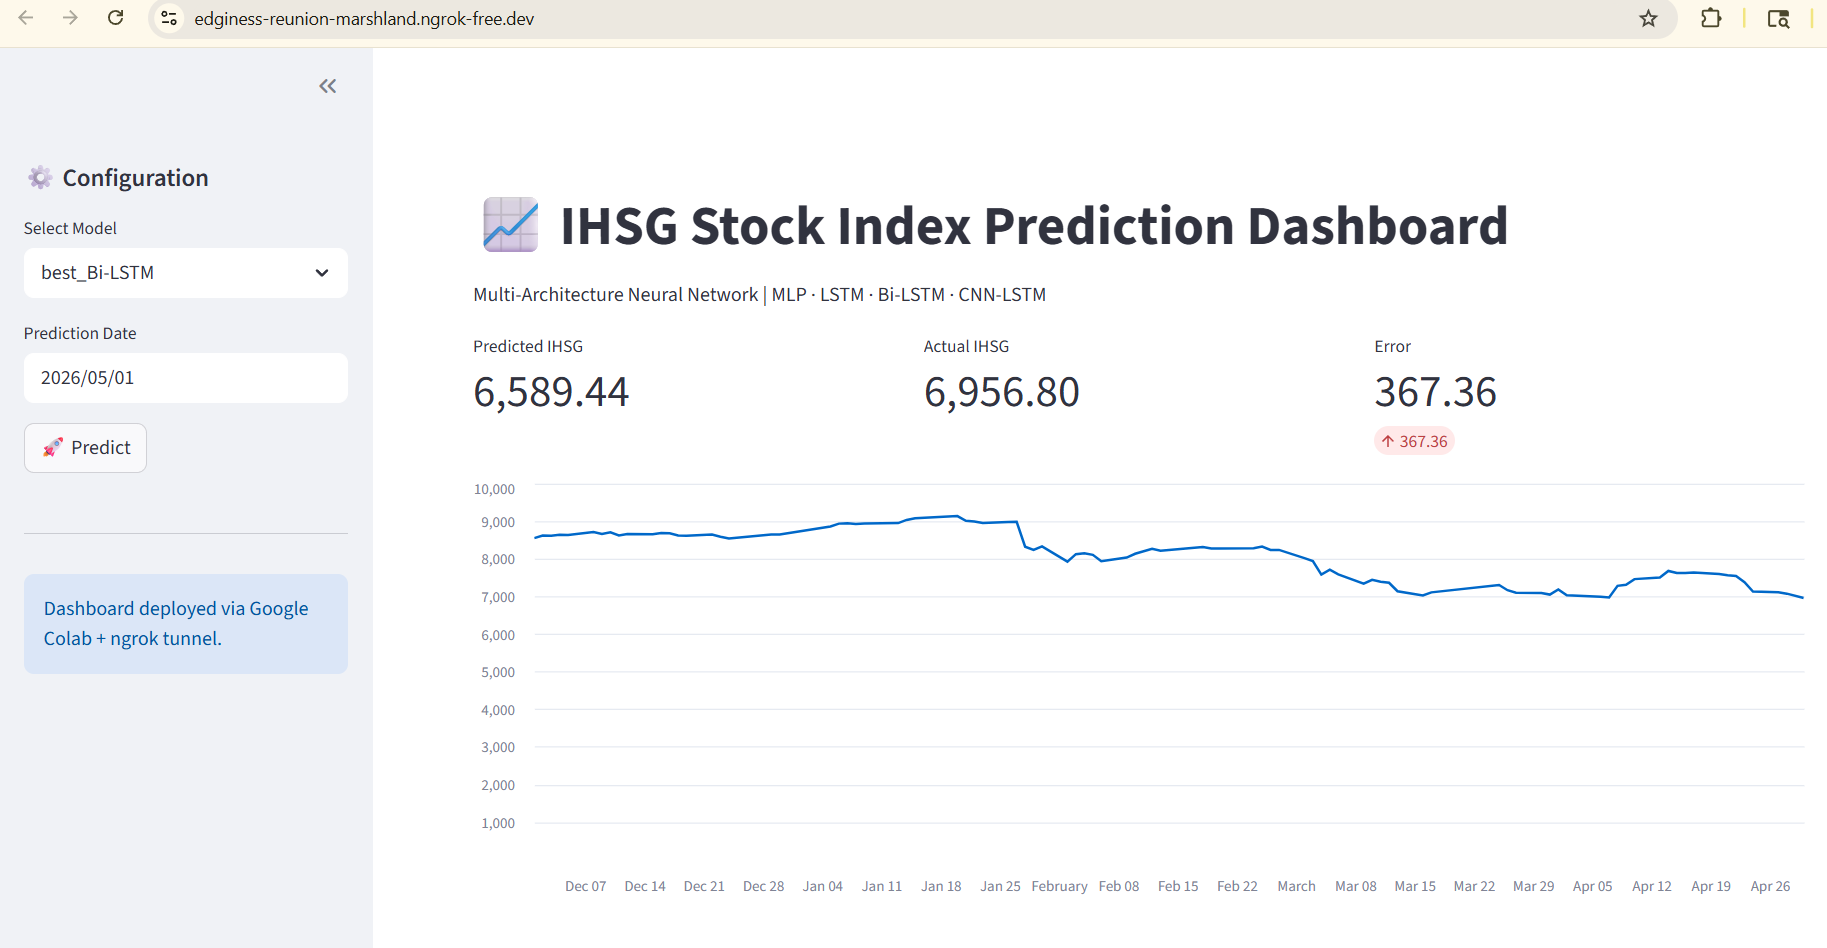

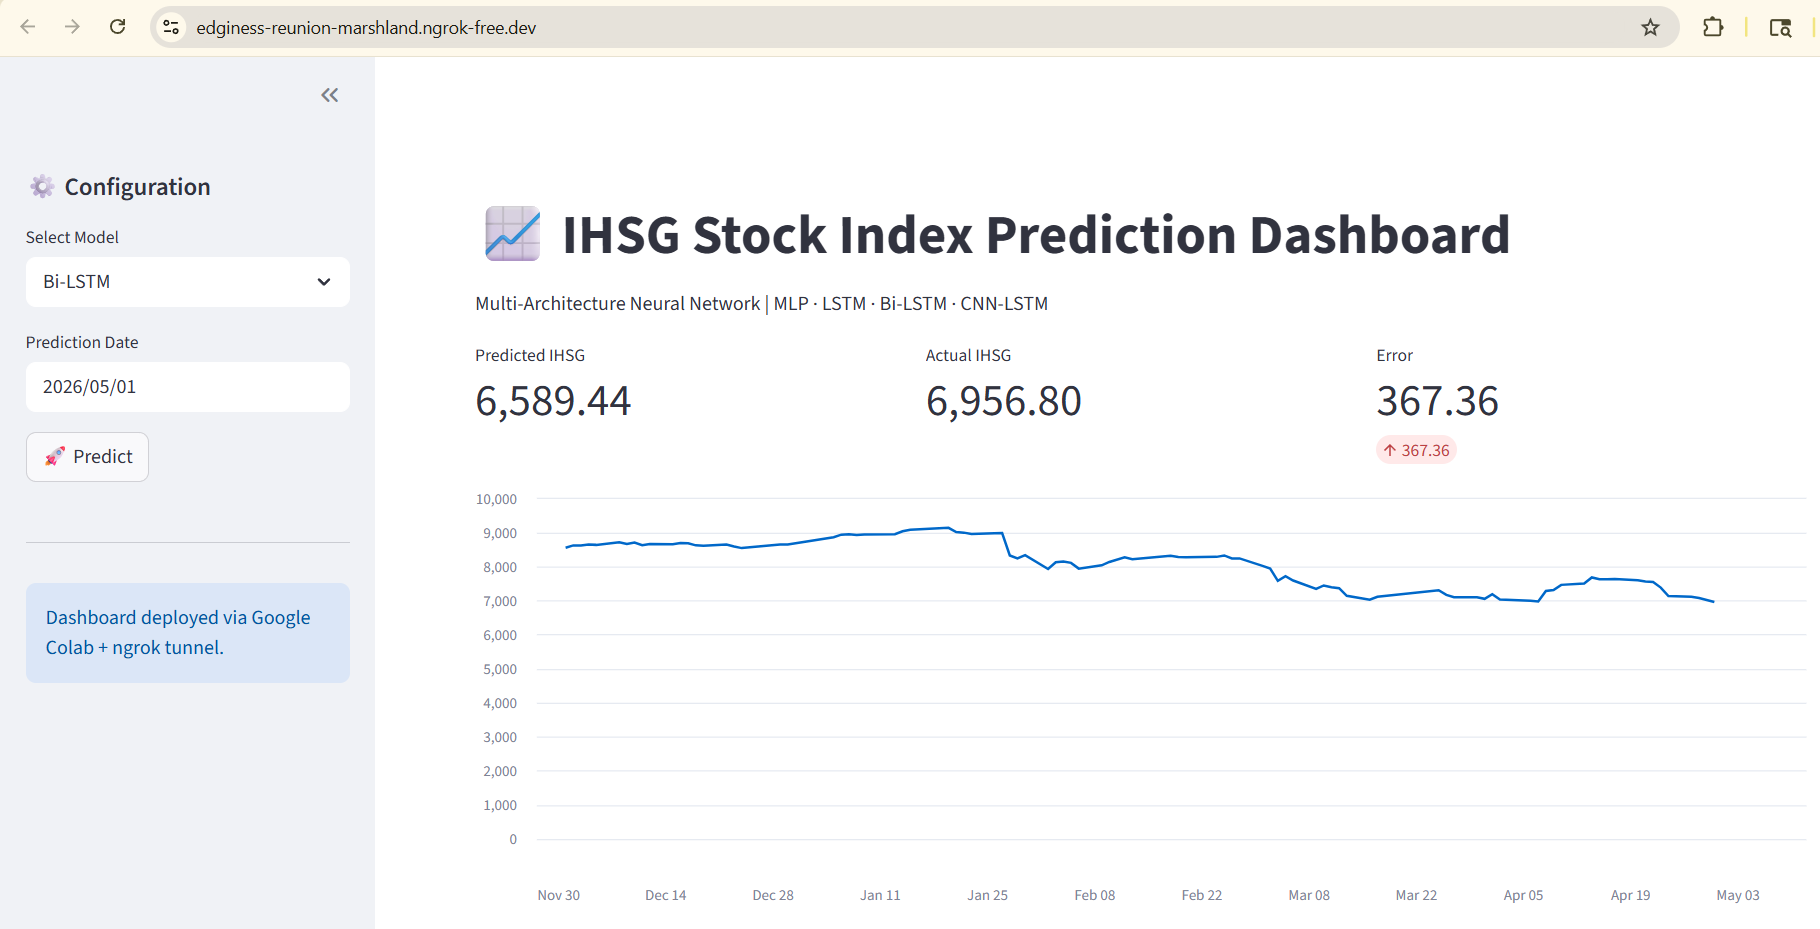

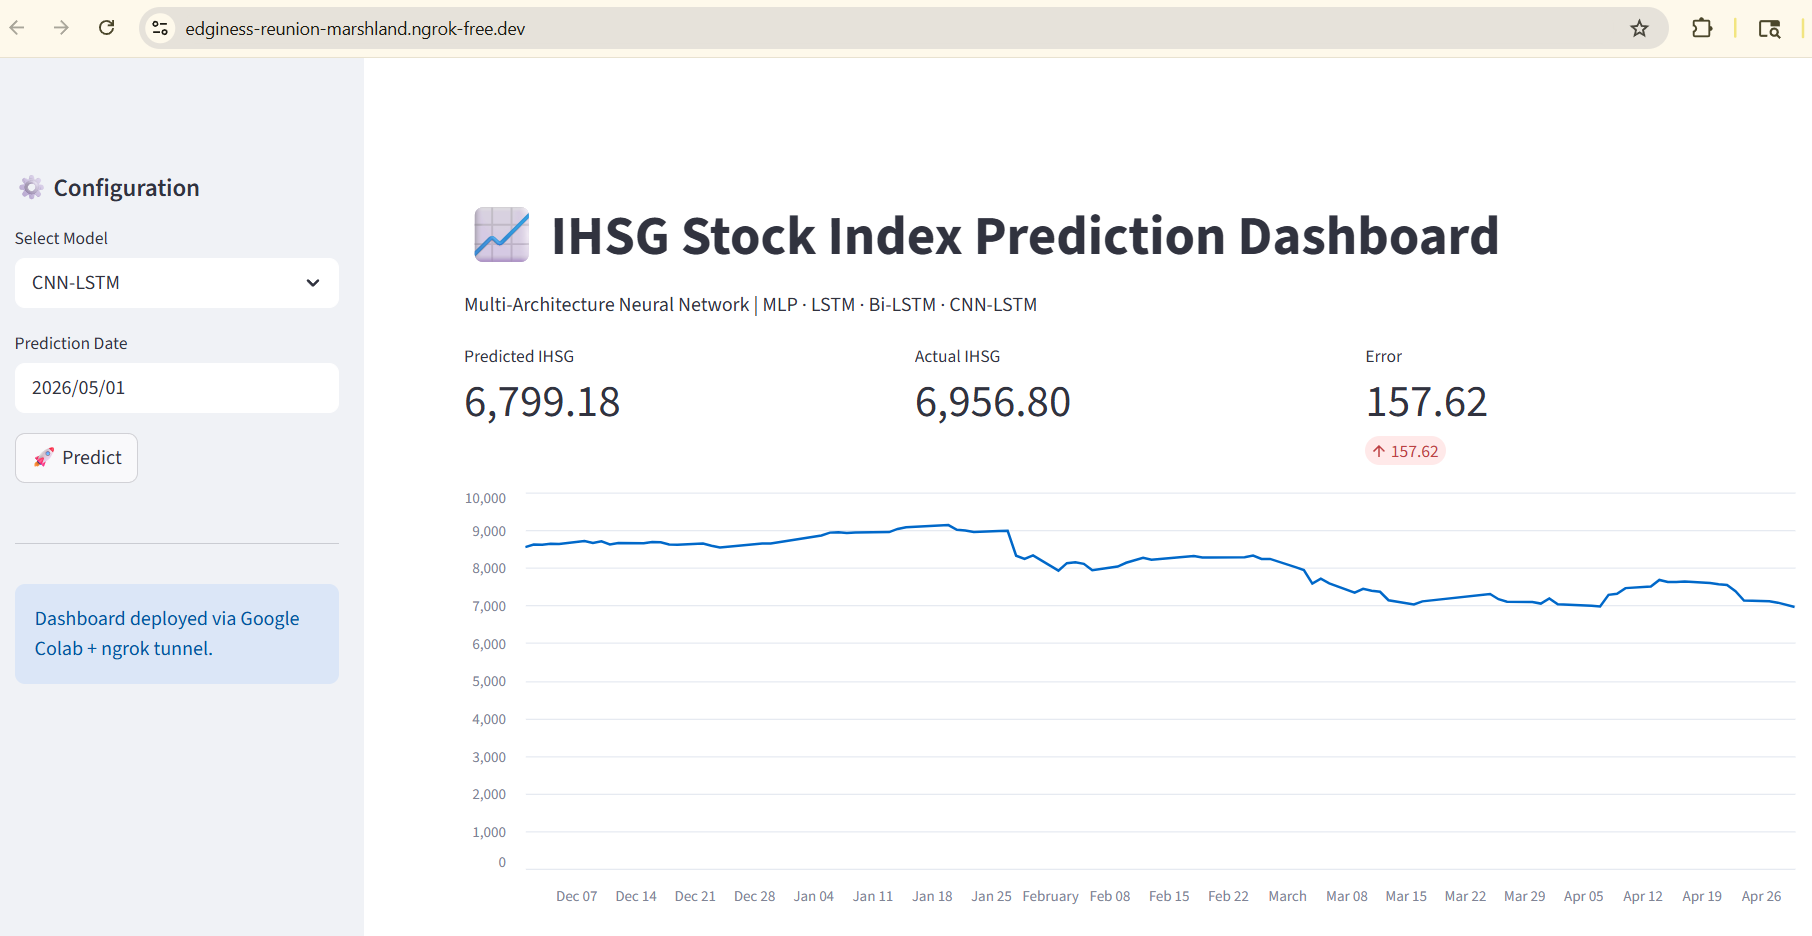

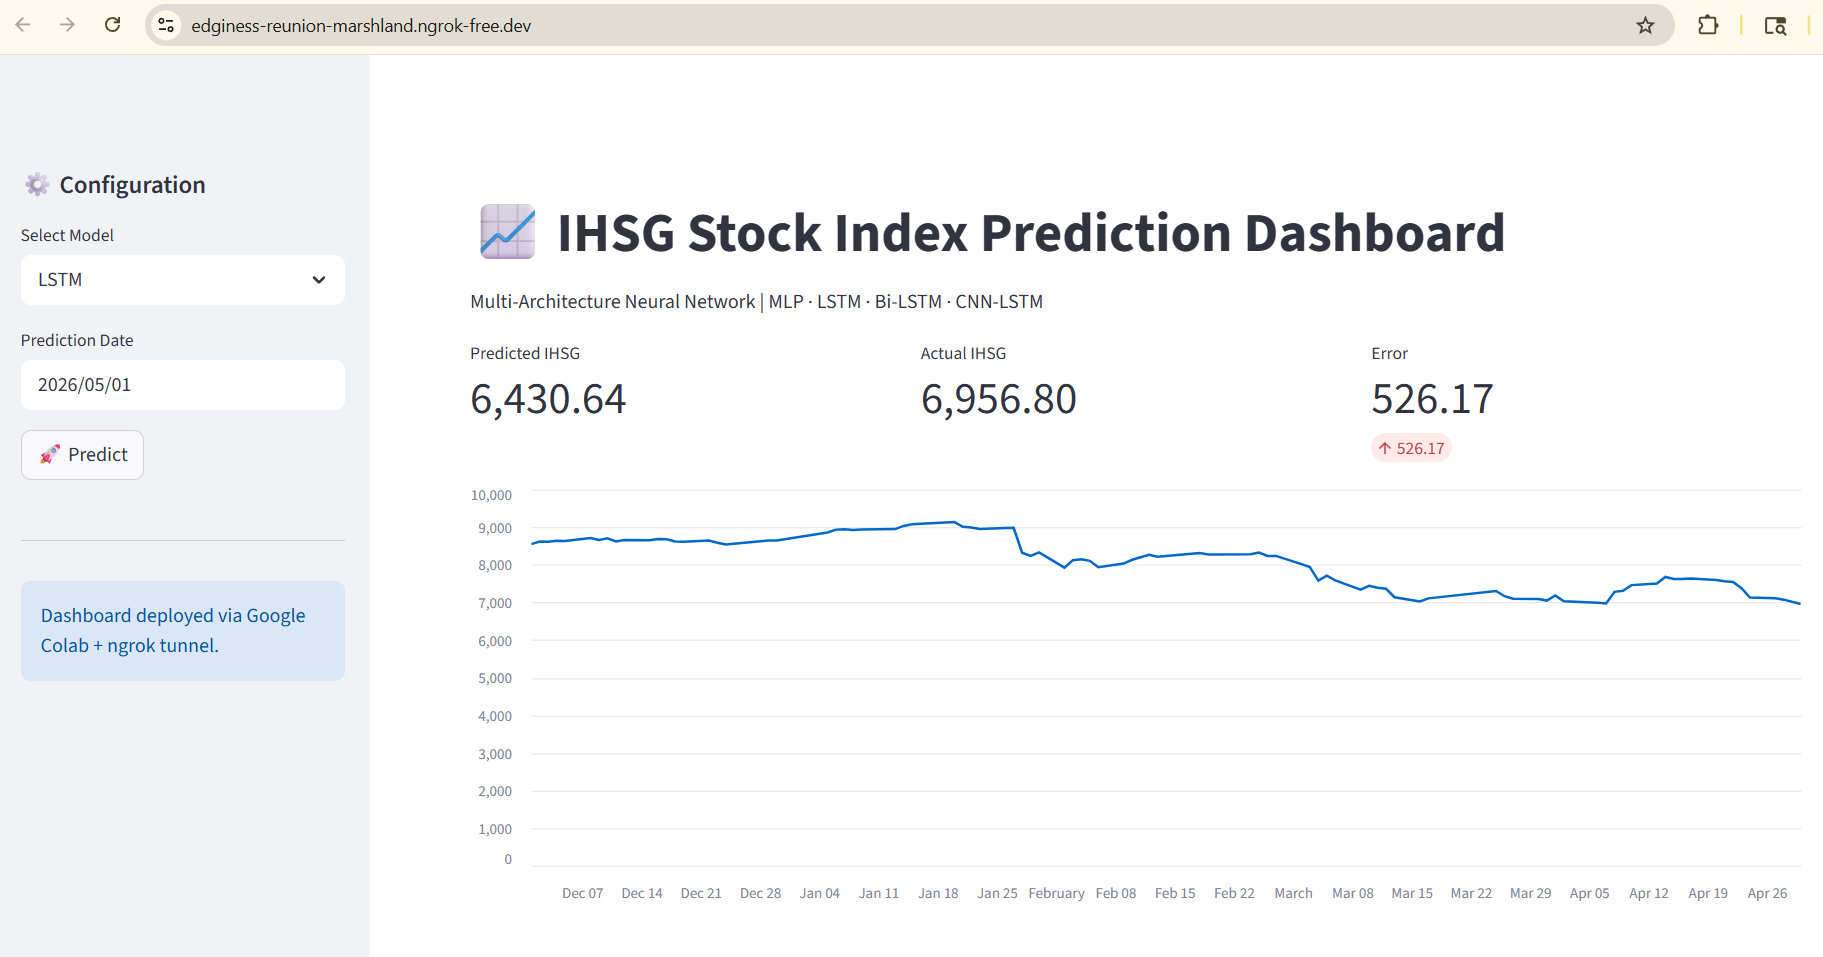

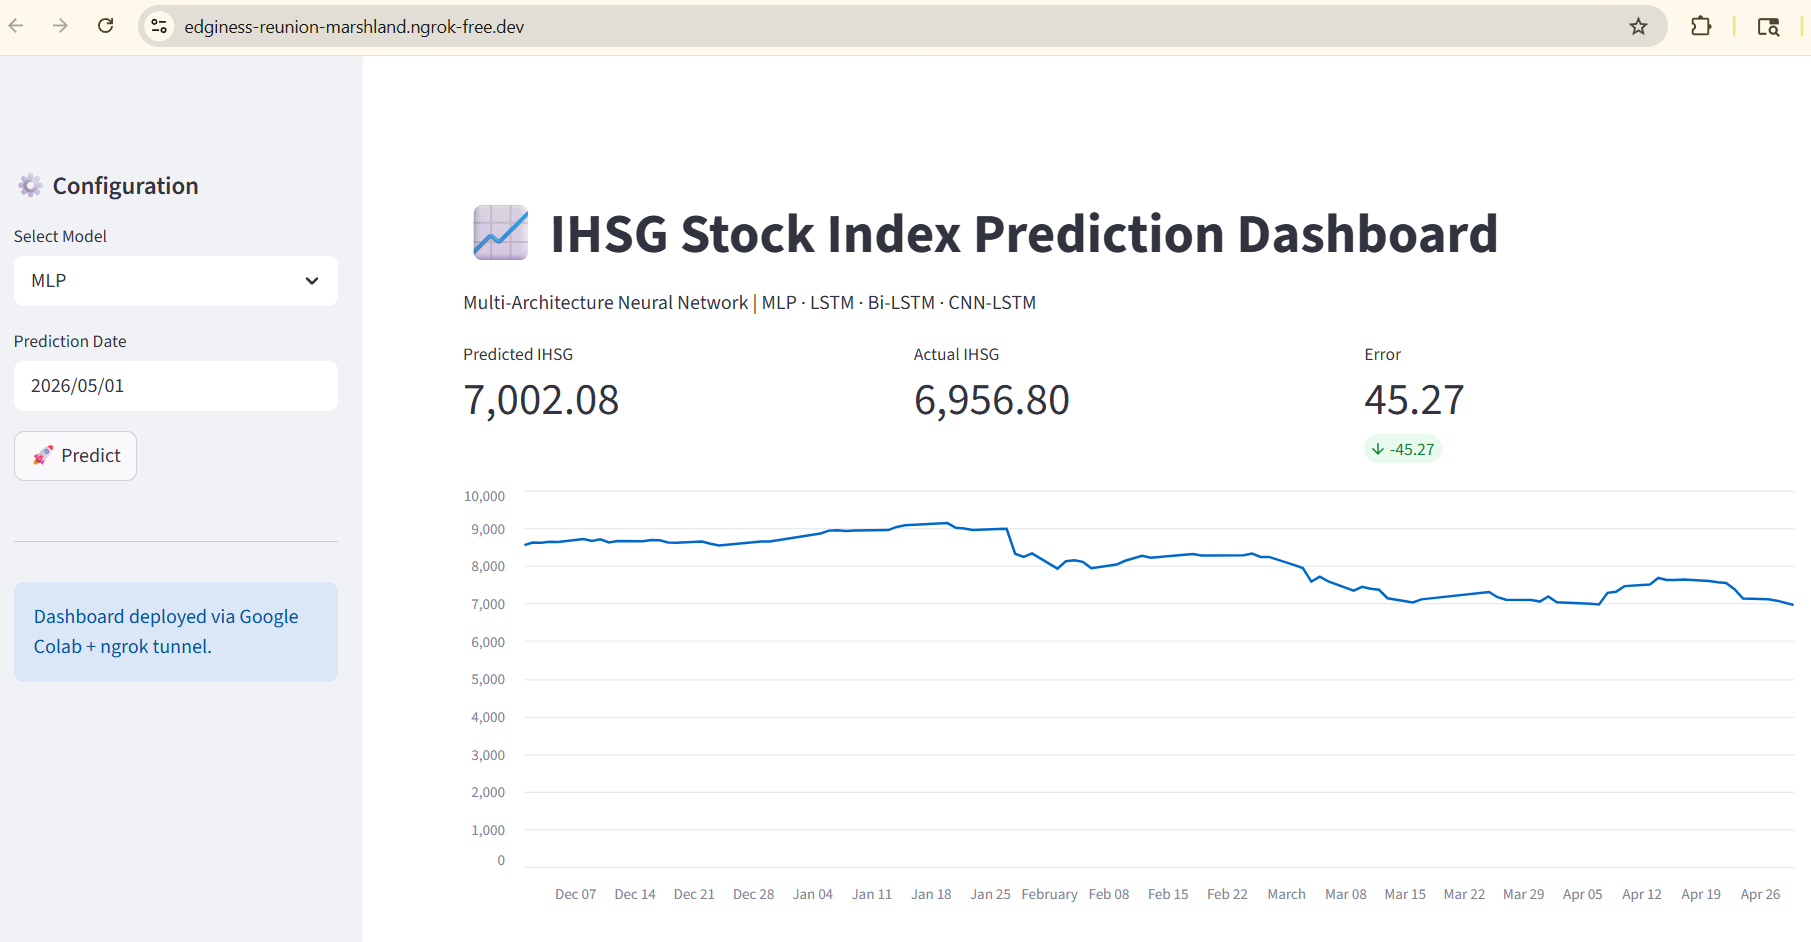